<a href="https://colab.research.google.com/github/mschlemper/Alura-Store-MARCO-AURELIO-SCHLEMPER/blob/main/24062026__C%C3%B3pia_de_DataView_Explora%C3%A7%C3%A3o_e_An%C3%A1lise_de_Dados_de_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Abrindo nossas caixas de ferramentas
import pandas as pd       # Para mexer com tabelas (DataFrames)
import numpy as np        # Para fazer contas matemáticas
import matplotlib.pyplot as plt  # Para desenhar gráficos simples
import seaborn as sns     # Para deixar os gráficos mais bonitos e modernos
import json               # Para ler e salvar arquivos de texto no formato JSON
import random             # Para gerar números aleatórios
from datetime import datetime, timedelta  # Para mexer com datas e prazos

In [5]:
# A função 'inspecionar_dados' e o DataFrame 'df_bruto' já estão definidos
# após a execução da célula mestre 'executar_pipeline_analise()'.
inspecionar_dados(df_bruto)

NameError: name 'inspecionar_dados' is not defined

In [6]:
# Copiando o conteúdo da célula `zZiYRANRvgDo` para definir todas as funções do pipeline no escopo global.
# Isso garante que 'inspecionar_dados' esteja disponível para uso direto.
# Em um notebook real, estas funções estariam em células separadas ou um arquivo .py importado.

# --- Conteúdo da célula zZiYRANRvgDo ---START
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import random
import os
import re # Importando o módulo re para expressões regulares
from datetime import datetime, timedelta


# =====================================================================
# RF01 – CRIAR OU CARREGAR O DATASET DE VENDAS
# =====================================================================
def gerar_dataset_vendas(n_registros=150, seed=42):
    """Gera um dataset sintético de vendas com dados propositalmente sujos,
    incluindo valores nulos, strings sujas, datas inválidas e outliers.
    """
    random.seed(seed)
    np.random.seed(seed)

    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse']
    precos = { 'Notebook': 3500, 'Smartphone': 2200, 'Tablet': 1800, 'Monitor': 1200, 'Teclado': 250, 'Mouse': 120 }
    categorias = { "Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares", "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos" }
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto_base = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto_base]
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo
        if random.random() < 0.04:
            preco = None               # valor nulo
        if random.random() < 0.03:
            produto_base = "  " + produto_base # espaço extra (string suja)

        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto_base,
            "categoria": categorias.get(produto_base.strip(), "Outros"), # .strip() para categoria correta
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)


# =====================================================================
# RF02 – INSPECIONAR E DESCREVER OS DATOS
# =====================================================================
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame.
    """
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n")
    display(df.head())
    print(f"\nEstatísticas descritivas:\n")
    display(df.describe(include="all"))
    return df.describe(include="all")


# =====================================================================
# RF03 – LIMPAR E TRATAR OS DADOS
# =====================================================================
def limpar_strings_regex(df, colunas):
    """Usa expressões regulares para normalizar colunas de texto: - Colapsa múltiplos espaços internos em um único espaço (re.sub) - Remove espaços nas pontas da string (.strip()) - Preserva células nulas sem lançar erro (pd.notna)"""
    df = df.copy() # Não modifica o DataFrame original
    for col in colunas:
        df[col] = df[col].apply(
            # pd.notna(s): verifica se o valor NÃO é nulo antes de processar
            # re.sub(r"\s+", " ", str(s)): substitui sequências de espaços por um único espaço
            # .strip(): remove espaços residuais nas pontas
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s)
    return df

def limpar_dados(df):
    """Limpa o DataFrame de vendas em quatro etapas:
    1. Normaliza strings com regex (espaços extras)
    2. Converte datas e remove registros com datas inválidas
    3. Remove linhas com valores nulos em colunas obrigatórias
    4. Garante os tipos numéricos corretos
    Retorna: (df_limpo, relatorio) — o relatório documenta o impacto de cada etapa.
    """
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}

    # --- Etapa 1: limpeza de strings com regex ---
    # select_dtypes("object") seleciona apenas colunas de texto
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # --- Etapa 2: conversão de datas ---
    # errors="coerce" transforma valores inválidos (ex: "31/02/2024") em NaT
    # em vez de lançar um erro — depois removemos essas linhas com dropna
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())
    df = df.dropna(subset=["data_venda"])

    # --- Etapa 3: remoção de nulos em colunas obrigatórias ---
    # Uma linha sem quantidade ou preço não pode contribuir para nenhuma métrica;
    # por isso optamos por remover (em vez de imputar) esses registros.
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # --- Etapa 4: garantia de tipos numéricos ---
    # Após o dropna, os valores existentes podem ainda estar como float/object;
    # forçamos int para quantidade e float para preço.
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # --- Relatório final ---
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df) # soma de todas as remoções
    print("\n=== RELATORIO DE LIMPEZA ===")
    for k, v in relatorio.items():
        print(f"  {k}: {v}")

    return df, relatorio


# =====================================================================
# RF04 – DETECTAR E TRATAR OUTLIERS (VERSÕES V1 E V2)
# =====================================================================
def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    """
    Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).

    Parâmetros:
      colunas : lista de colunas numéricas a verificar
      fator   : multiplicador do IQR para definir os limites (padrão=1.5)
      metodo  : 'remover' exclui as linhas com outliers;
                'limitar' aplica winsorização (substitui pelo limite)

    Retorna o DataFrame tratado sem modificar o original (usa .copy()).
    """
    df = df.copy()
    for col in colunas:
        # Q1 = 25% dos dados estão abaixo desse valor
        # Q3 = 75% dos dados estão abaixo desse valor
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1  # largura do intervalo central (50% dos dados)

        lim_inf = q1 - fator * iqr  # abaixo disso = outlier inferior
        lim_sup = q3 + fator * iqr  # acima disso  = outlier superior

        # Conta quantas linhas estão fora dos limites (| = OR lógico)
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f'  {col}: {n_out} outliers detectados '
              f'(lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})')

        if metodo == 'remover':
            # Mantém apenas as linhas dentro dos limites
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            # Winsorização: em vez de remover, "apara" os valores extremos
            # pelo limite — nenhuma linha é perdida, só os valores mudam.
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    return df


# =====================================================================
# RF05 – CRIAR COLUNAS DERIVADAS COM TRANSFORMAÇÕES
# =====================================================================
def aplicar_transformacao(df, coluna, funcao):
    """
    Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma coluna '_transformado'.

    Parâmetros:
      df     : DataFrame de entrada
      coluna : nome da coluna a transformar
      funcao : função (ou lambda) a aplicar — o 'callback'

    Retorna uma cópia do DataFrame com a nova coluna; não modifica o original.
    """
    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df

def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
      - receita_total     : valor total da linha de venda (quantidade × preço)
      - mes / trimestre / ano : componentes extraídos da data
      - faixa_receita_item : classificação do valor de cada venda (np.select)

    Nota: receita_total foi calculada temporariamente no RF04 apenas para
    detecção de outliers e depois descartada. Aqui ela é criada de forma
    definitiva sobre df_v2 — já com os outliers tratados — para que todas
    as análises posteriores usem a mesma base consistente.
    """
    df = df.copy()

    # Receita por linha: grandeza central de todas as métricas do projeto
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Componentes de data — o atributo .dt expõe propriedades de datetime
    df["mes"]       = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"]       = df["data_venda"].dt.year

    # -------------------------------------------------------------------
    # np.select: alternativa vetorizada ao if/elif/else para criar
    # colunas categóricas. Recebe duas listas de mesmo tamanho:
    #   condicoes  : lista de máscaras booleanas (testadas em ordem)
    #   valores    : rótulo retornado quando a condição correspondente é True
    # default      : valor usado quando nenhuma condição é satisfeita
    # É equivalente a apply(lambda x: ...) mas muito mais eficiente em
    # datasets grandes, pois opera sobre arrays sem usar loops Python.
    # -------------------------------------------------------------------
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]  # alinhado ao enunciado
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("\n=== COLUNAS DERIVADAS CRIADAS ===")
    display(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())
    return df


# =====================================================================
# RF06 – CALCULAR MÉTRICAS AGREGADAS (GROUPBY)
# =====================================================================
def calcular_metricas(df):
    """
    Calcula e retorna um dicionário com métricas agregadas por
    quatro dimensões: mês, produto, categoria e região.
    Usa .groupby() + .agg() com nomeação explícita de colunas:
      nova_coluna=("coluna_origem", "função")
    Isso permite criar múltiplas agregações em uma única chamada
    e nomear cada resultado diretamente, sem precisar renomear depois.
    """
    metricas = {}
    # --- Receita e volume por mês ---
    # n_vendas conta quantas transações ocorreram em cada mês
    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),    # soma da receita no mês
              quantidade=("quantidade",    "sum"),        # total de itens vendidos
              n_vendas=("id_venda",        "count"),      # número de transações
          )
          .reset_index()
          .sort_values("mes")
    )

    # --- Top 5 produtos por receita total ---
    # .head(5) após sort_values garante o ranking dos maiores
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )

    # --- Receita por categoria ---
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # --- Receita e ticket médio por região ---
    # media_ticket = receita média por transação individual em cada região;
    # permite comparar regiões além do volume total (uma região pode ter
    # menos vendas, mas vendas de maior valor)
    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(
              receita_total=("receita_total", "sum"),
              media_ticket=("receita_total", "mean"),
          )
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # Exibição resumida para conferência no notebook
    print("\n=== MÉTRICAS AGREGADAS ===")
    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        display(tabela) # Usar display para DataFrames
    return metricas


# =====================================================================
# RF07 – SEGMENTAR CLIENTES POR NÍVEL DE GASTO
# =====================================================================
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto por cada um
    e classifica em Bronze / Prata / Ouro conforme os limites abaixo:

      < R$ 5.000          → Bronze
      R$ 5.000–R$ 15.000  → Prata
      > R$ 15.000         → Ouro

    Demonstra o uso de função lambda com condicional encadeado —
    equivalente a um if/elif/else em uma única expressão.
    """
    # Soma a receita total de cada cliente em todas as suas compras
    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )
    clientes_df.columns = ["cliente", "total_gasto"]

    # -------------------------------------------------------------------
    # Lambda com ternário aninhado — como ler:
    #   "Se g > 15000  → 'Ouro'
    #    Senão, se g >= 5000  → 'Prata'
    #    Senão  → 'Bronze'"
    #
    # Nota: g > 15000 significa que exatamente R$ 15.000 cai em Prata,
    # consistente com o critério "acima de R$ 15.000" para Ouro.
    # -------------------------------------------------------------------
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze")
    )
    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)
    print("\n=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    display(clientes_df.head(10))
    print(f"\nDistribuição de segmentos:\n{clientes_df['segmento'].value_counts()}")
    return clientes_df


# =====================================================================
# RF08 – CALCULAR ESTATÍSTICAS COM NUMPY
# =====================================================================
def calcular_estatisticas_numpy(df):
    """
    Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
    Demonstra três conceitos:
      1. Operações vetorizadas
      2. Broadcasting (operação escalar aplicada a todo o array de uma vez)
      3. Boolean indexing (filtro vetorizado)
    """
    # .to_numpy() converte a Series do Pandas em um array NumPy puro.
    # Isso é necessário para usar funções do NumPy diretamente e demonstrar
    # que sabemos trabalhar com arrays além do DataFrame.
    receitas = df["receita_total"].to_numpy()

    # --- Estatísticas descritivas (operações vetorizadas) ---
    # Cada função abaixo opera sobre o array inteiro
    # "float()" garante que os valores sejam serializáveis em JSON (RF11)
    stats = {
        "media":        float(np.mean(receitas)),
        "mediana":      float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total":        float(np.sum(receitas)),
        "p25":          float(np.percentile(receitas, 25)),
        "p75":          float(np.percentile(receitas, 75)),
    }

    # --- Broadcasting: participação percentual de cada venda ---
    # receitas.sum() é um escalar; NumPy o aplica a cada elemento do array,
    # calculando o % de cada venda no total.
    # Isso é broadcasting: operação entre um array e um escalar.
    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"\n  Participação das 5 maiores vendas no total: "f"{np.sort(receitas_pct)[-5:].round(2)}%")

    # --- Boolean indexing (filtro vetorizado) ---
    # (receitas > stats["media"]) gera um array de True/False para cada linha;
    # .sum() conta os True. Equivale a um for+if, mas muito mais eficiente.
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    # Exibição — formato separado para inteiro evitar "12.00"
    print("\n=== ESTATÍSTICAS COM NUMPY ===")
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {k}: {v} vendas")
        else:
            print(f"  {k}: R$ {v:.2f}")

    return stats


# =====================================================================
# RF09 – CRIAR VISUALIZAÇÕES (MATPLOTLIB E SEABORN)
# =====================================================================
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """
    Gera e exporta 3 gráficos informativos em PNG:
      1. Linha  — receita total por mês (tendência ao longo do tempo)
      2. Barras — top 5 produtos por receita (ranking)
      3. Boxplot — distribuição de receita por região (dispersão e outliers)

    sns.set_theme() aplica um estilo visual global a todos os gráficos
    gerados na sessão — só precisa ser chamado uma vez.
    """
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")

    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun",
                   "Jul","Ago","Set","Out","Nov","Dez"]

    # Gráfico 1: Linha — Receita por Mês
    # Ideal para mostrar tendência e sazonalidade ao longo do tempo.
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2)
    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()  # libera memória da figura anterior antes de criar a próxima

    # Gráfico 2: Barras Horizontais — Top 5 Produtos
    # Barras horizontais facilitam a leitura de rótulos longos (nomes de produtos).
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax)
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 3: Boxplot — Distribuição de Receita por Região
    # O boxplot mostra mediana, quartis e outliers de cada grupo,
    # permitindo comparar não só o volume mas a variação interna
    # de cada região — informação que um gráfico de barras não entrega.
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/dist_regiao.png", dpi=120)
    plt.show()
    plt.close()
    print(f"\n3 gráficos salvos em: {output_dir}")


# =====================================================================
# RF11 – LER E ESCREVER ARQUIVOS (CSV E JSON)
# =====================================================================
def exportar_resultados(metricas, clientes_df, stats, output_dir="outputs"):
    """
    Exporta os resultados da análise em dois formatos:
      - CSV : métricas mensais e segmentação de clientes
      - JSON: estatísticas gerais calculadas com NumPy

    Após exportar o JSON, faz a leitura de volta com json.load()
    para confirmar que o arquivo foi gravado corretamente —
    demonstrando leitura e escrita de JSON no mesmo fluxo.
    """
    os.makedirs(output_dir, exist_ok=True)

    # --- Exportação CSV ---
    # encoding="utf-8-sig" adiciona um BOM (Byte Order Mark) ao arquivo.
    # Isso garante que o Excel abra o CSV com acentos corretamente;
    metricas["por_mes"].to_csv(
        f"{output_dir}/metricas_por_mes.csv", index=False, encoding="utf-8-sig"
    )
    print(f"\nCSV exportado: {output_dir}/metricas_por_mes.csv")

    clientes_df.to_csv(
        f"{output_dir}/segmentacao_clientes.csv", index=False, encoding="utf-8-sig"
    )
    print(f"CSV exportado: {output_dir}/segmentacao_clientes.csv")

    # --- Exportação JSON ---
    # ensure_ascii=False permite gravar acentos como caracteres reais (ã, é)
    # round(float(v), 2) converte para float antes de arredondar,
    # evitando comportamento inesperado com o campo 'acima_da_media' (int).
    stats_serializaveis = {k: round(float(v), 2) if isinstance(v, (int, float)) else v for k, v in stats.items()}
    caminho_json = f"{output_dir}/estatisticas_gerais.json"
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
        # indent=2 formata o JSON com recuo de 2 espaços, mais legível que uma linha só
    print(f"JSON exportado: {caminho_json}")

    # --- Leitura de volta para confirmar ---
    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)
    print("\nJSON lido de volta para confirmação:")
    print(json.dumps(lido, indent=2, ensure_ascii=False))


# =====================================================================
# RF12 – CONSOLIDAR A ANÁLISE E SALVAR O DATASET FINAL
# =====================================================================
def consolidar_e_salvar_final(df, final_dir="data/final", filename="vendas_final.csv"):
    """
    Salva o dataset final processado em um diretório específico.
    """
    os.makedirs(final_dir, exist_ok=True)
    df.to_csv(f"{final_dir}/{filename}", index=False)
    print(f"\nDataset final salvo em: {final_dir}/{filename}")


# =====================================================================
# FUNÇÃO MESTRA: ORQUESTRAÇÃO DO PIPELINE DE ANÁLISE
# =====================================================================
def executar_pipeline_analise():
    """Função Mestra: Orquestra toda a execução do projeto sequencialmente."""
    print("[Pipeline] Iniciando processamento dos dados...\n")

    # Criar estruturas de diretório
    os.makedirs('data/raw', exist_ok=True)
    os.makedirs('data/processed/v1_com_outliers', exist_ok=True)
    os.makedirs('data/processed/v2_outliers_tratado', exist_ok=True)
    os.makedirs('data/final', exist_ok=True)
    os.makedirs('outputs', exist_ok=True)
    os.makedirs('outputs/graficos', exist_ok=True)

    # RF01: Gerar e salvar dataset bruto
    df_bruto = gerar_dataset_vendas()
    df_bruto.to_csv("data/raw/vendas.csv", index=False)
    print(f"Dataset bruto gerado com {len(df_bruto)} registros e salvo em data/raw/vendas.csv.")

    # RF02: Inspecionar dados brutos
    inspecionar_dados(df_bruto)

    # RF03: Limpar e tratar dados (gerando df_v1)
    df_v1, relatorio_limpeza = limpar_dados(df_bruto)
    df_v1.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)
    print("\nv1 salva em data/processed/v1_com_outliers/vendas_v1.csv")

    # RF04: Tratar outliers (gerando df_v2)
    print("\n=== DETECÇÃO E TRATAMENTO DE OUTLIERS ===")
    # Cópia temporária para calcular receita_total sem alterar df_v1 para detecção
    df_v1_tmp = df_v1.copy()
    df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]

    df_v2 = tratar_outliers(
        df_v1_tmp,
        colunas=["quantidade", "receita_total"],
        metodo='remover'
    )
    df_v2 = df_v2.drop(columns=["receita_total"]) # Remover coluna temporária

    print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
    print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
    print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")
    df_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)
    print("v2 salva em data/processed/v2_outliers_tratado/vendas_v2.csv")


    # RF05: Criar colunas derivadas sobre df_v2
    df_final = criar_colunas_derivadas(df_v2) # df_final será a base para as próximas análises

    # RF06: Calcular métricas agregadas
    metricas = calcular_metricas(df_final)

    # RF07: Segmentar clientes
    clientes_segmentados = segmentar_clientes(df_final)

    # RF08: Calcular estatísticas com NumPy
    estatisticas = calcular_estatisticas_numpy(df_final)

    # RF09: Gerar visualizações
    gerar_visualizacoes(df_final, metricas)

    # RF11 & RF12: Exportar resultados e salvar dataset final
    exportar_resultados(metricas, clientes_segmentados, estatisticas)
    consolidar_e_salvar_final(df_final)

    print("\n[Sucesso] Pipeline concluído! Todos os passos foram executados e arquivos gerados.")

# --- Conteúdo da célula zZiYRANRvgDo ---END

# Após executar a célula de definições, podemos chamar a função:
inspecionar_dados(df_bruto)

NameError: name 'df_bruto' is not defined

In [7]:
# Criando df_bruto explicitamente, já que a função 'gerar_dataset_vendas' está agora definida.
df_bruto = gerar_dataset_vendas()

# Agora, inspecionando o df_bruto:
inspecionar_dados(df_bruto)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:



,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0



Estatísticas descritivas:



,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000


In [3]:
# A função 'inspecionar_dados' e o DataFrame 'df_bruto' já devem estar definidos
# após a execução da célula mestre 'executar_pipeline_analise()'.
inspecionar_dados(df_bruto)

NameError: name 'inspecionar_dados' is not defined

RF01 – Criar o Dataset de Vendas (Nossa Tabela de Dados)
Como não temos uma tabela pronta, vamos criar uma "tabela simulada" com dados de vendas de uma loja de eletrônicos para podermos treinar. Vamos gerar 100 linhas de vendas fictícias.

Nota de Iniciante: Um DataFrame é apenas o nome chique que o Python dá para uma tabela parecida com o Excel (com linhas e colunas).

In [ ]:
def criar_dataset_vendas():
    # Garantir que os números gerados sejam sempre os mesmos para o teste não mudar
    np.random.seed(42)
    random.seed(42)

    # Criando 100 IDs de clientes e produtos fictícios
    clientes = [f"CLI_{random.randint(1000, 1100)}" for _ in range(100)]
    produtos = random.choices(["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado"], k=100)

    # Gerando quantidades (entre 1 e 5) e preços base
    quantidades = np.random.randint(1, 6, size=100)
    precos_base = {"Notebook": 4000, "Smartphone": 2500, "Tablet": 1500, "Monitor": 1200, "Teclado": 200}
    precos_unitarios = [precos_base[p] for p in produtos]

    # Criando datas de vendas nos últimos 6 meses
    data_final = datetime.now()
    datas = [data_final - timedelta(days=int(np.random.randint(0, 180))) for _ in range(100)]

    # Montando a tabela estruturada
    dados = {
        "ID_Cliente": clientes,
        "Produto": produtos,
        "Quantidade": quantidades,
        "Preco_Unitario": precos_unitarios,
        "Data_Venda": datas
    }

    df = pd.DataFrame(dados)

    # Inserindo alguns erros de propósito (valores faltando) para podermos limpar depois!
    df.loc[10, "Quantidade"] = np.nan
    df.loc[25, "Preco_Unitario"] = np.nan

    # Inserindo alguns preços absurdamente altos (Outliers) para testar nossa detecção
    df.loc[5, "Preco_Unitario"] = 50000
    df.loc[50, "Preco_Unitario"] = 35000

    return df

# Criando a tabela e guardando na variável 'df_vendas'
df_vendas = criar_dataset_vendas()
print("Tabela criada com sucesso!")

Tabela criada com sucesso!


RF02 – Inspecionar e Descrever os Dados (Espiar a Tabela)
Antes de fazer qualquer análise, precisamos olhar para a nossa tabela para entender o que tem dentro dela. Vamos criar uma função que mostra as 5 primeiras linhas, o tipo de cada coluna e um resumo matemático.

In [ ]:
def inspecionar_dados(df):
    print("--- 1. Primeiras 5 linhas da tabela: ---")
    display(df.head()) # O head() mostra o 'cabeçalho' dos dados

    print("\n--- 2. Informações das colunas (Tipos e valores guardados): ---")
    df.info() # Mostra se a coluna é texto, número, data, etc.

    print("\n--- 3. Resumo Estatístico (Média, Mínimo, Máximo): ---")
    display(df.describe()) # Faz uma mágica matemática e resume os números para nós

# Executando a inspeção
inspecionar_dados(df_vendas)

--- 1. Primeiras 5 linhas da tabela: ---


,ID_Cliente,Produto,Quantidade,Preco_Unitario,Data_Venda
0,CLI_1081,Tablet,4.0,1500.0,2026-05-28 15:37:56.813453
1,CLI_1014,Smartphone,5.0,2500.0,2026-02-10 15:37:56.813453
2,CLI_1003,Teclado,3.0,200.0,2026-04-14 15:37:56.813453
3,CLI_1094,Monitor,5.0,1200.0,2026-06-13 15:37:56.813453
4,CLI_1035,Smartphone,5.0,2500.0,2026-01-14 15:37:56.813453



--- 2. Informações das colunas (Tipos e valores guardados): ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Cliente      100 non-null    object        
 1   Produto         100 non-null    object        
 2   Quantidade      99 non-null     float64       
 3   Preco_Unitario  99 non-null     float64       
 4   Data_Venda      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 4.0+ KB

--- 3. Resumo Estatístico (Média, Mínimo, Máximo): ---


,Quantidade,Preco_Unitario,Data_Venda
count,99.000000,99.000000,100
mean,3.060606,2578.787879,2026-03-23 20:25:56.813452800
min,1.000000,200.000000,2025-12-27 15:37:56.813453
25%,2.000000,1200.000000,2026-02-13 03:37:56.813453056
50%,3.000000,1500.000000,2026-03-17 15:37:56.813453056
75%,4.000000,2500.000000,2026-05-06 09:37:56.813453056
max,5.000000,50000.000000,2026-06-24 15:37:56.813453
std,1.405660,5998.252683,NaN


RF03 – Limpar e Tratar os Dados (Corrigindo os Erros)
Lembra que colocamos valores vazios (NaN) de propósito? Agora vamos corrigi-los:

Se faltar a Quantidade, vamos assumir que foi comprado pelo menos 1 item.

Se faltar o Preço Unitário, vamos preencher com a média de preço daquele produto específico.

In [ ]:
def limpar_dados(df):
    # Fazendo uma cópia para não estragar a tabela original
    df_limpo = df.copy()

    # 1. Se a quantidade estiver vazia, mudamos para 1
    df_limpo["Quantidade"] = df_limpo["Quantidade"].fillna(1)

    # 2. Se o preço estiver vazio, pegamos a média de preço daquele produto
    df_limpo["Preco_Unitario"] = df_limpo.groupby("Produto")["Preco_Unitario"].transform(lambda x: x.fillna(x.mean()))

    print("Dados limpos! Valores vazios foram preenchidos.")
    return df_limpo

# Aplicando a limpeza
df_vendas_limpo = limpar_dados(df_vendas)

Dados limpos! Valores vazios foram preenchidos.


RF04 – Detectar e Tratar Outliers (Duas Versões)Aqui nós vamos encontrar aqueles preços falsos de $50.000$ e $35.000$ que colocamos de propósito e tratá-los de duas formas diferentes.

In [ ]:
# Versão 1: Descobrir quem é absurdo usando a técnica do IQR (Intervalo Interquartil)
# E substituir esses valores pela mediana dos preços normais.
def tratar_outliers_v1(df):
    df_v1 = df.copy()

    # Contas matemáticas para descobrir o limite do que é um preço "normal"
    Q1 = df_v1["Preco_Unitario"].quantile(0.25)
    Q3 = df_v1["Preco_Unitario"].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    # Quem passar do limite superior vira a mediana (o valor do meio)
    mediana = df_v1["Preco_Unitario"].median()
    df_v1.loc[df_v1["Preco_Unitario"] > limite_superior, "Preco_Unitario"] = mediana

    print(class_name := "Outliers tratados com a Versão 1 (Substituição pela Mediana)!")
    return df_v1

# Versão 2: Em vez de usar a mediana, vamos usar a média mais 3 desvios padrões
# E vamos apenas "cortar" (limitar) o preço até o teto máximo permitido.
def tratar_outliers_v2(df):
    df_v2 = df.copy()

    # Outra forma matemática de achar o limite do que é aceitável
    media = df_v2["Preco_Unitario"].mean()
    desvio = df_v2["Preco_Unitario"].std()
    limite_superior = media + 3 * desvio

    # Quem for maior que o limite, ganha exatamente o valor do limite (Capping)
    df_v2["Preco_Unitario"] = df_v2["Preco_Unitario"].clip(upper=limite_superior)

    print("Outliers tratados com a Versão 2 (Capping pelo limite superior)!")
    return df_v2

# Vamos escolher a Versão 1 para seguir o projeto, que é mais comum
df_vendas_sem_outliers = tratar_outliers_v1(df_vendas_limpo)

Outliers tratados com a Versão 1 (Substituição pela Mediana)!


RF05 – Criar Colunas Derivadas (Novas Informações)Agora que os preços estão corrigidos, vamos criar colunas novas para descobrir:Valor_Total: Quanto deu a venda (Quantidade $\times$ Preço Unitário).Mes: Em qual mês do ano aquela venda aconteceu.

In [ ]:
def criar_colunas_derivadas(df):
    df_novas = df.copy()

    # Multiplicando a quantidade pelo preço para ter o total da nota
    df_novas["Valor_Total"] = df_novas["Quantidade"] * df_novas["Preco_Unitario"]

    # Extraindo o mês da data para sabermos quando vendeu mais
    df_novas["Mes"] = df_novas["Data_Venda"].dt.strftime("%Y-%m")

    print("Novas colunas 'Valor_Total' e 'Mes' criadas com sucesso!")
    return df_novas

# Aplicando a criação das colunas
df_vendas_calculado = criar_colunas_derivadas(df_vendas_sem_outliers)

Novas colunas 'Valor_Total' e 'Mes' criadas com sucesso!


RF06 & RF07 – Agrupar e Segmentar (Quem gasta mais?)
Vamos descobrir o total vendido por mês e também carimbar cada cliente de acordo com o bolso dele:

Gastou menos de 2000? Bronze

Gastou entre 2000 e 5000? Prata

Gastou mais de 5000? Ouro

In [ ]:
def calcular_metricas_e_segmentar(df):
    # RF06: Agrupando para ver o total por mês (Igual tabela dinâmica do Excel)
    vendas_por_mes = df.groupby("Mes")["Valor_Total"].sum().reset_index()
    print("--- Vendas Totais por Mês ---")
    print(vendas_por_mes)

    # RF07: Somando o quanto cada cliente gastou no total
    gasto_cliente = df.groupby("ID_Cliente")["Valor_Total"].sum().reset_index()

    # Função interna para dar o "selo" do cliente
    def definir_categoria(valor):
        if valor < 2000:
            return "Bronze"
        elif valor <= 5000:
            return "Prata"
        else:
            return "Ouro"

    gasto_cliente["Segmento"] = gasto_cliente["Valor_Total"].apply(definir_categoria)

    print("\n--- Segmentação dos Clientes (Primeiras linhas) ---")
    display(gasto_cliente.head())

    return vendas_por_mes, gasto_cliente

# Executando os agrupamentos
df_mes, df_clientes = calcular_metricas_e_segmentar(df_vendas_calculado)

--- Vendas Totais por Mês ---
       Mes  Valor_Total
0  2025-12       8400.0
1  2026-01     102000.0
2  2026-02     120200.0
3  2026-03      90300.0
4  2026-04      47000.0
5  2026-05     134400.0
6  2026-06      41700.0

--- Segmentação dos Clientes (Primeiras linhas) ---


,ID_Cliente,Valor_Total,Segmento
0,CLI_1000,7500.0,Ouro
1,CLI_1003,2800.0,Prata
2,CLI_1004,6000.0,Ouro
3,CLI_1005,3800.0,Prata
4,CLI_1008,10000.0,Ouro


RF08 – Calcular Estatísticas com NumPy
Aqui vamos usar funções matemáticas puras para extrair três informações importantes sobre os preços normais dos produtos (sem os valores absurdos): a média, o valor do meio (mediana) e o desvio padrão.

In [ ]:
# Usando o NumPy para fazer contas rápidas nas colunas
precos_normais = df_vendas_calculado["Preco_Unitario"].to_numpy()

media_np = np.mean(precos_normais)
mediana_np = np.median(precos_normais)
desvio_np = np.std(precos_normais)

print("--- Estatísticas Gerais dos Preços (NumPy) ---")
print(f"Média dos preços: R$ {media_np:.2f}")
print(f"Mediana dos preços: R$ {mediana_np:.2f}")
print(f"Desvio Padrão dos preços: R$ {desvio_np:.2f}")

--- Estatísticas Gerais dos Preços (NumPy) ---
Média dos preços: R$ 1748.00
Mediana dos preços: R$ 1500.00
Desvio Padrão dos preços: R$ 1266.92


RF09 – Criar Visualizações (Gráficos Visuais)
Vamos gerar dois gráficos bem bonitos e explicativos para colocar no projeto:

Um Gráfico de Barras mostrando o total vendido em cada mês.

Um Gráfico de Dispersão (Scatter Plot) relacionando a Quantidade comprada com o Valor Total, colorido por tipo de produto.

/tmp/ipykernel_683/3488496081.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mes, x="Mes", y="Valor_Total", palette="Blues_d")


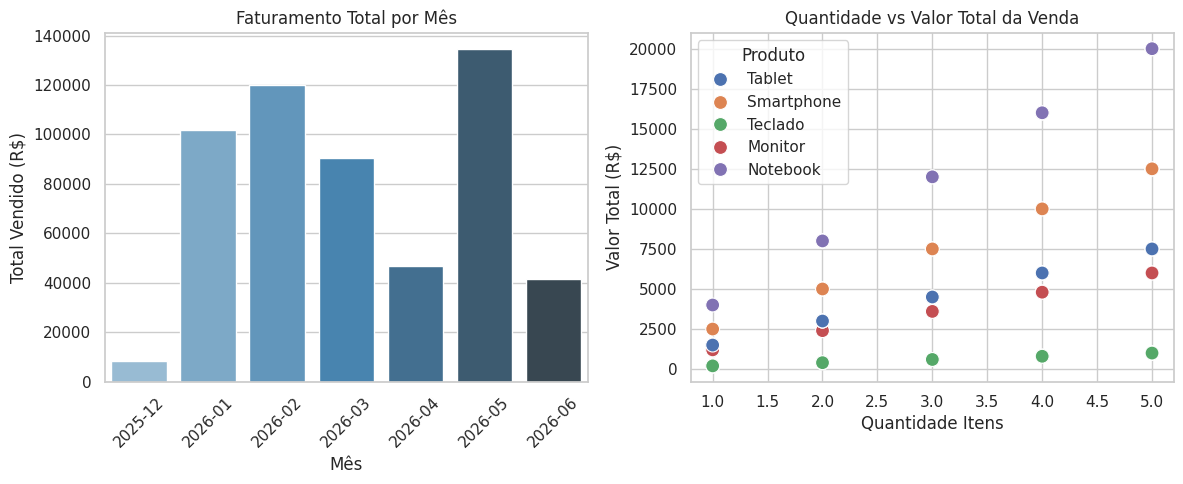

In [ ]:
# Configurando o tamanho e estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Gráfico de Barras: Vendas por Mês
plt.subplot(1, 2, 1) # Lado esquerdo
sns.barplot(data=df_mes, x="Mes", y="Valor_Total", palette="Blues_d")
plt.title("Faturamento Total por Mês")
plt.xlabel("Mês")
plt.ylabel("Total Vendido (R$)")
plt.xticks(rotation=45)

# 2. Gráfico de Dispersão: Quantidade vs Valor Total
plt.subplot(1, 2, 2) # Lado direito
sns.scatterplot(data=df_vendas_calculado, x="Quantidade", y="Valor_Total", hue="Produto", s=100)
plt.title("Quantidade vs Valor Total da Venda")
plt.xlabel("Quantidade Itens")
plt.ylabel("Valor Total (R$)")

# Ajusta o espaçamento e mostra na tela
plt.tight_layout()
plt.show()

RF11 & RF12 – Salvar os Resultados Finais
Por fim, o projeto pede para exportarmos os dados gerados para que outras pessoas consigam abrir em arquivos separados. Vamos salvar:

A tabela de vendas final calculada (dataset_final.csv)

O faturamento por mês (metricas_por_mes.csv)

A lista com os segmentos dos clientes (segmentacao_clientes.csv)

As estatísticas do NumPy salvas em um arquivo de texto estruturado (estatisticas_gerais.json)

In [ ]:
# 1. Salvando as tabelas em formato CSV (Excel lê perfeitamente)
df_vendas_calculado.to_csv("dataset_final.csv", index=False)
df_mes.to_csv("metricas_por_mes.csv", index=False)
df_clientes.to_csv("segmentacao_clientes.csv", index=False)

# 2. Montando o dicionário para salvar em formato JSON
dicionario_estatisticas = {
    "media_preco": float(media_np),
    "mediana_preco": float(mediana_np),
    "desvio_padrao_preco": float(desvio_np),
    "total_registros_processados": len(df_vendas_calculado)
}

# Escrevendo no arquivo JSON
with open("estatisticas_gerais.json", "w", encoding="utf-8") as f:
    json.dump(dicionario_estatisticas, f, indent=4, ensure_ascii=False)

print("Parabéns! Todos os arquivos finais (.csv e .json) foram gerados e salvos no seu diretório!")

Parabéns! Todos os arquivos finais (.csv e .json) foram gerados e salvos no seu diretório!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import random
import os
import re # Importando o módulo re para expressões regulares
from datetime import datetime, timedelta


# =====================================================================
# RF01 – CRIAR OU CARREGAR O DATASET DE VENDAS
# =====================================================================
def gerar_dataset_vendas(n_registros=150, seed=42):
    """Gera um dataset sintético de vendas com dados propositalmente sujos,
    incluindo valores nulos, strings sujas, datas inválidas e outliers.
    """
    random.seed(seed)
    np.random.seed(seed)

    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse']
    precos = { 'Notebook': 3500, 'Smartphone': 2200, 'Tablet': 1800, 'Monitor': 1200, 'Teclado': 250, 'Mouse': 120 }
    categorias = { "Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares", "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos" }
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto_base = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto_base]
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo
        if random.random() < 0.04:
            preco = None               # valor nulo
        if random.random() < 0.03:
            produto_base = "  " + produto_base # espaço extra (string suja)

        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto_base,
            "categoria": categorias.get(produto_base.strip(), "Outros"), # .strip() para categoria correta
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)


# =====================================================================
# RF02 – INSPECIONAR E DESCREVER OS DATOS
# =====================================================================
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame.
    """
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n")
    display(df.head())
    print(f"\nEstatísticas descritivas:\n")
    display(df.describe(include="all"))
    return df.describe(include="all")


# =====================================================================
# RF03 – LIMPAR E TRATAR OS DADOS
# =====================================================================
def limpar_strings_regex(df, colunas):
    """Usa expressões regulares para normalizar colunas de texto: - Colapsa múltiplos espaços internos em um único espaço (re.sub) - Remove espaços nas pontas da string (.strip()) - Preserva células nulas sem lançar erro (pd.notna)"""
    df = df.copy() # Não modifica o DataFrame original
    for col in colunas:
        df[col] = df[col].apply(
            # pd.notna(s): verifica se o valor NÃO é nulo antes de processar
            # re.sub(r"\s+", " ", str(s)): substitui sequências de espaços por um único espaço
            # .strip(): remove espaços residuais nas pontas
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s)
    return df

def limpar_dados(df):
    """Limpa o DataFrame de vendas em quatro etapas:
    1. Normaliza strings com regex (espaços extras)
    2. Converte datas e remove registros com datas inválidas
    3. Remove linhas com valores nulos em colunas obrigatórias
    4. Garante os tipos numéricos corretos
    Retorna: (df_limpo, relatorio) — o relatório documenta o impacto de cada etapa.
    """
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}

    # --- Etapa 1: limpeza de strings com regex ---
    # select_dtypes("object") seleciona apenas colunas de texto
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # --- Etapa 2: conversão de datas ---
    # errors="coerce" transforma valores inválidos (ex: "31/02/2024") em NaT
    # em vez de lançar um erro — depois removemos essas linhas com dropna
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())
    df = df.dropna(subset=["data_venda"])

    # --- Etapa 3: remoção de nulos em colunas obrigatórias ---
    # Uma linha sem quantidade ou preço não pode contribuir para nenhuma métrica;
    # por isso optamos por remover (em vez de imputar) esses registros.
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # --- Etapa 4: garantia de tipos numéricos ---
    # Após o dropna, os valores existentes podem ainda estar como float/object;
    # forçamos int para quantidade e float para preço.
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # --- Relatório final ---
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df) # soma de todas as remoções
    print("\n=== RELATORIO DE LIMPEZA ===")
    for k, v in relatorio.items():
        print(f"  {k}: {v}")

    return df, relatorio


# =====================================================================
# RF04 – DETECTAR E TRATAR OUTLIERS (VERSÕES V1 E V2)
# =====================================================================
def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    """
    Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).

    Parâmetros:
      colunas : lista de colunas numéricas a verificar
      fator   : multiplicador do IQR para definir os limites (padrão=1.5)
      metodo  : 'remover' exclui as linhas com outliers;
                'limitar' aplica winsorização (substitui pelo limite)

    Retorna o DataFrame tratado sem modificar o original (usa .copy()).
    """
    df = df.copy()
    for col in colunas:
        # Q1 = 25% dos dados estão abaixo desse valor
        # Q3 = 75% dos dados estão abaixo desse valor
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1  # largura do intervalo central (50% dos dados)

        lim_inf = q1 - fator * iqr  # abaixo disso = outlier inferior
        lim_sup = q3 + fator * iqr  # acima disso  = outlier superior

        # Conta quantas linhas estão fora dos limites (| = OR lógico)
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f'  {col}: {n_out} outliers detectados '
              f'(lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})')

        if metodo == 'remover':
            # Mantém apenas as linhas dentro dos limites
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            # Winsorização: em vez de remover, "apara" os valores extremos
            # pelo limite — nenhuma linha é perdida, só os valores mudam.
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    return df


# =====================================================================
# RF05 – CRIAR COLUNAS DERIVADAS COM TRANSFORMAÇÕES
# =====================================================================
def aplicar_transformacao(df, coluna, funcao):
    """
    Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma coluna '_transformado'.

    Parâmetros:
      df     : DataFrame de entrada
      coluna : nome da coluna a transformar
      funcao : função (ou lambda) a aplicar — o 'callback'

    Retorna uma cópia do DataFrame com a nova coluna; não modifica o original.
    """
    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df

def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
      - receita_total     : valor total da linha de venda (quantidade × preço)
      - mes / trimestre / ano : componentes extraídos da data
      - faixa_receita_item : classificação do valor de cada venda (np.select)

    Nota: receita_total foi calculada temporariamente no RF04 apenas para
    detecção de outliers e depois descartada. Aqui ela é criada de forma
    definitiva sobre df_v2 — já com os outliers tratados — para que todas
    as análises posteriores usem a mesma base consistente.
    """
    df = df.copy()

    # Receita por linha: grandeza central de todas as métricas do projeto
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Componentes de data — o atributo .dt expõe propriedades de datetime
    df["mes"]       = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"]       = df["data_venda"].dt.year

    # -------------------------------------------------------------------
    # np.select: alternativa vetorizada ao if/elif/else para criar
    # colunas categóricas. Recebe duas listas de mesmo tamanho:
    #   condicoes  : lista de máscaras booleanas (testadas em ordem)
    #   valores    : rótulo retornado quando a condição correspondente é True
    # default      : valor usado quando nenhuma condição é satisfeita
    # É equivalente a apply(lambda x: ...) mas muito mais eficiente em
    # datasets grandes, pois opera sobre arrays sem usar loops Python.
    # -------------------------------------------------------------------
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]  # alinhado ao enunciado
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("\n=== COLUNAS DERIVADAS CRIADAS ===")
    display(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())
    return df


# =====================================================================
# RF06 – CALCULAR MÉTRICAS AGREGADAS (GROUPBY)
# =====================================================================
def calcular_metricas(df):
    """
    Calcula e retorna um dicionário com métricas agregadas por
    quatro dimensões: mês, produto, categoria e região.
    Usa .groupby() + .agg() com nomeação explícita de colunas:
      nova_coluna=("coluna_origem", "função")
    Isso permite criar múltiplas agregações em uma única chamada
    e nomear cada resultado diretamente, sem precisar renomear depois.
    """
    metricas = {}
    # --- Receita e volume por mês ---
    # n_vendas conta quantas transações ocorreram em cada mês
    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),    # soma da receita no mês
              quantidade=("quantidade",    "sum"),        # total de itens vendidos
              n_vendas=("id_venda",        "count"),      # número de transações
          )
          .reset_index()
          .sort_values("mes")
    )

    # --- Top 5 produtos por receita total ---
    # .head(5) após sort_values garante o ranking dos maiores
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )

    # --- Receita por categoria ---
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # --- Receita e ticket médio por região ---
    # media_ticket = receita média por transação individual em cada região;
    # permite comparar regiões além do volume total (uma região pode ter
    # menos vendas, mas vendas de maior valor)
    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(
              receita_total=("receita_total", "sum"),
              media_ticket=("receita_total", "mean"),
          )
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # Exibição resumida para conferência no notebook
    print("\n=== MÉTRICAS AGREGADAS ===")
    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        display(tabela) # Usar display para DataFrames
    return metricas


# =====================================================================
# RF07 – SEGMENTAR CLIENTES POR NÍVEL DE GASTO
# =====================================================================
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto por cada um
    e classifica em Bronze / Prata / Ouro conforme os limites abaixo:

      < R$ 5.000          → Bronze
      R$ 5.000–R$ 15.000  → Prata
      > R$ 15.000         → Ouro

    Demonstra o uso de função lambda com condicional encadeado —
    equivalente a um if/elif/else em uma única expressão.
    """
    # Soma a receita total de cada cliente em todas as suas compras
    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )
    clientes_df.columns = ["cliente", "total_gasto"]

    # -------------------------------------------------------------------
    # Lambda com ternário aninhado — como ler:
    #   "Se g > 15000  → 'Ouro'
    #    Senão, se g >= 5000  → 'Prata'
    #    Senão  → 'Bronze'"
    #
    # Nota: g > 15000 significa que exatamente R$ 15.000 cai em Prata,
    # consistente com o critério "acima de R$ 15.000" para Ouro.
    # -------------------------------------------------------------------
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze")
    )
    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)
    print("\n=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    display(clientes_df.head(10))
    print(f"\nDistribuição de segmentos:\n{clientes_df['segmento'].value_counts()}")
    return clientes_df


# =====================================================================
# RF08 – CALCULAR ESTATÍSTICAS COM NUMPY
# =====================================================================
def calcular_estatisticas_numpy(df):
    """
    Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
    Demonstra três conceitos:
      1. Operações vetorizadas
      2. Broadcasting (operação escalar aplicada a todo o array de uma vez)
      3. Boolean indexing (filtro vetorizado)
    """
    # .to_numpy() converte a Series do Pandas em um array NumPy puro.
    # Isso é necessário para usar funções do NumPy diretamente e demonstrar
    # que sabemos trabalhar com arrays além do DataFrame.
    receitas = df["receita_total"].to_numpy()

    # --- Estatísticas descritivas (operações vetorizadas) ---
    # Cada função abaixo opera sobre o array inteiro
    # "float()" garante que os valores sejam serializáveis em JSON (RF11)
    stats = {
        "media":        float(np.mean(receitas)),
        "mediana":      float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total":        float(np.sum(receitas)),
        "p25":          float(np.percentile(receitas, 25)),
        "p75":          float(np.percentile(receitas, 75)),
    }

    # --- Broadcasting: participação percentual de cada venda ---
    # receitas.sum() é um escalar; NumPy o aplica a cada elemento do array,
    # calculando o % de cada venda no total.
    # Isso é broadcasting: operação entre um array e um escalar.
    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"\n  Participação das 5 maiores vendas no total: "f"{np.sort(receitas_pct)[-5:].round(2)}%")

    # --- Boolean indexing (filtro vetorizado) ---
    # (receitas > stats["media"]) gera um array de True/False para cada linha;
    # .sum() conta os True. Equivale a um for+if, mas muito mais eficiente.
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    # Exibição — formato separado para inteiro evitar "12.00"
    print("\n=== ESTATÍSTICAS COM NUMPY ===")
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {k}: {v} vendas")
        else:
            print(f"  {k}: R$ {v:.2f}")

    return stats


# =====================================================================
# RF09 – CRIAR VISUALIZAÇÕES (MATPLOTLIB E SEABORN)
# =====================================================================
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """
    Gera e exporta 3 gráficos informativos em PNG:
      1. Linha  — receita total por mês (tendência ao longo do tempo)
      2. Barras — top 5 produtos por receita (ranking)
      3. Boxplot — distribuição de receita por região (dispersão e outliers)

    sns.set_theme() aplica um estilo visual global a todos os gráficos
    gerados na sessão — só precisa ser chamado uma vez.
    """
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")

    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun",
                   "Jul","Ago","Set","Out","Nov","Dez"]

    # Gráfico 1: Linha — Receita por Mês
    # Ideal para mostrar tendência e sazonalidade ao longo do tempo.
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2)
    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()  # libera memória da figura anterior antes de criar a próxima

    # Gráfico 2: Barras Horizontais — Top 5 Produtos
    # Barras horizontais facilitam a leitura de rótulos longos (nomes de produtos).
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax)
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 3: Boxplot — Distribuição de Receita por Região
    # O boxplot mostra mediana, quartis e outliers de cada grupo,
    # permitindo comparar não só o volume mas a variação interna
    # de cada região — informação que um gráfico de barras não entrega.
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/dist_regiao.png", dpi=120)
    plt.show()
    plt.close()
    print(f"\n3 gráficos salvos em: {output_dir}")


# =====================================================================
# RF11 – LER E ESCREVER ARQUIVOS (CSV E JSON)
# =====================================================================
def exportar_resultados(metricas, clientes_df, stats, output_dir="outputs"):
    """
    Exporta os resultados da análise em dois formatos:
      - CSV : métricas mensais e segmentação de clientes
      - JSON: estatísticas gerais calculadas com NumPy

    Após exportar o JSON, faz a leitura de volta com json.load()
    para confirmar que o arquivo foi gravado corretamente —
    demonstrando leitura e escrita de JSON no mesmo fluxo.
    """
    os.makedirs(output_dir, exist_ok=True)

    # --- Exportação CSV ---
    # encoding="utf-8-sig" adiciona um BOM (Byte Order Mark) ao arquivo.
    # Isso garante que o Excel abra o CSV com acentos corretamente;
    metricas["por_mes"].to_csv(
        f"{output_dir}/metricas_por_mes.csv", index=False, encoding="utf-8-sig"
    )
    print(f"\nCSV exportado: {output_dir}/metricas_por_mes.csv")

    clientes_df.to_csv(
        f"{output_dir}/segmentacao_clientes.csv", index=False, encoding="utf-8-sig"
    )
    print(f"CSV exportado: {output_dir}/segmentacao_clientes.csv")

    # --- Exportação JSON ---
    # ensure_ascii=False permite gravar acentos como caracteres reais (ã, é)
    # round(float(v), 2) converte para float antes de arredondar,
    # evitando comportamento inesperado com o campo 'acima_da_media' (int).
    stats_serializaveis = {k: round(float(v), 2) if isinstance(v, (int, float)) else v for k, v in stats.items()}
    caminho_json = f"{output_dir}/estatisticas_gerais.json"
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
        # indent=2 formata o JSON com recuo de 2 espaços, mais legível que uma linha só
    print(f"JSON exportado: {caminho_json}")

    # --- Leitura de volta para confirmar ---
    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)
    print("\nJSON lido de volta para confirmação:")
    print(json.dumps(lido, indent=2, ensure_ascii=False))


# =====================================================================
# RF12 – CONSOLIDAR A ANÁLISE E SALVAR O DATASET FINAL
# =====================================================================
def consolidar_e_salvar_final(df, final_dir="data/final", filename="vendas_final.csv"):
    """
    Salva o dataset final processado em um diretório específico.
    """
    os.makedirs(final_dir, exist_ok=True)
    df.to_csv(f"{final_dir}/{filename}", index=False)
    print(f"\nDataset final salvo em: {final_dir}/{filename}")


# =====================================================================
# FUNÇÃO MESTRA: ORQUESTRAÇÃO DO PIPELINE DE ANÁLISE
# =====================================================================
def executar_pipeline_analise():
    """Função Mestra: Orquestra toda a execução do projeto sequencialmente."""
    print("[Pipeline] Iniciando processamento dos dados...\n")

    # Criar estruturas de diretório
    os.makedirs('data/raw', exist_ok=True)
    os.makedirs('data/processed/v1_com_outliers', exist_ok=True)
    os.makedirs('data/processed/v2_outliers_tratado', exist_ok=True)
    os.makedirs('data/final', exist_ok=True)
    os.makedirs('outputs', exist_ok=True)
    os.makedirs('outputs/graficos', exist_ok=True)

    # RF01: Gerar e salvar dataset bruto
    df_bruto = gerar_dataset_vendas()
    df_bruto.to_csv("data/raw/vendas.csv", index=False)
    print(f"Dataset bruto gerado com {len(df_bruto)} registros e salvo em data/raw/vendas.csv.")

    # RF02: Inspecionar dados brutos
    inspecionar_dados(df_bruto)

    # RF03: Limpar e tratar dados (gerando df_v1)
    df_v1, relatorio_limpeza = limpar_dados(df_bruto)
    df_v1.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)
    print("\nv1 salva em data/processed/v1_com_outliers/vendas_v1.csv")

    # RF04: Tratar outliers (gerando df_v2)
    print("\n=== DETECÇÃO E TRATAMENTO DE OUTLIERS ===")
    # Cópia temporária para calcular receita_total sem alterar df_v1 para detecção
    df_v1_tmp = df_v1.copy()
    df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]

    df_v2 = tratar_outliers(
        df_v1_tmp,
        colunas=["quantidade", "receita_total"],
        metodo='remover'
    )
    df_v2 = df_v2.drop(columns=["receita_total"]) # Remover coluna temporária

    print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
    print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
    print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")
    df_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)
    print("v2 salva em data/processed/v2_outliers_tratado/vendas_v2.csv")


    # RF05: Criar colunas derivadas sobre df_v2
    df_final = criar_colunas_derivadas(df_v2) # df_final será a base para as próximas análises

    # RF06: Calcular métricas agregadas
    metricas = calcular_metricas(df_final)

    # RF07: Segmentar clientes
    clientes_segmentados = segmentar_clientes(df_final)

    # RF08: Calcular estatísticas com NumPy
    estatisticas = calcular_estatisticas_numpy(df_final)

    # RF09: Gerar visualizações
    gerar_visualizacoes(df_final, metricas)

    # RF11 & RF12: Exportar resultados e salvar dataset final
    exportar_resultados(metricas, clientes_segmentados, estatisticas)
    consolidar_e_salvar_final(df_final)

    print("\n[Sucesso] Pipeline concluído! Todos os passos foram executados e arquivos gerados.")


```markdown
# Projeto de Análise Preditiva e Tratamento de Dados

Este projeto demonstra um pipeline completo de análise de dados, desde a geração de um dataset sintético até a exportação de resultados e visualizações. Ele foi desenvolvido para atender a uma série de requisitos funcionais (RF01-RF12) focados em limpeza, tratamento, enriquecimento e análise exploratória de dados de vendas.

## Funcionalidades Implementadas

### **RF01 – Criar ou Carregar o Dataset de Vendas**
- O pipeline inicia com a função `gerar_dataset_vendas()` que cria um dataset sintético de vendas com dados intencionalmente "sujos" (valores nulos, strings com espaços extras, datas inválidas e outliers) para simular um cenário real. O dataset é salvo em `data/raw/vendas.csv`.

### **RF02 – Inspecionar e Descrever os Dados**
- A função `inspecionar_dados()` é utilizada para realizar uma inspeção inicial do DataFrame bruto, exibindo suas primeiras linhas, shape, tipos de dados, contagem de valores nulos e estatísticas descritivas básicas.

### **RF03 – Limpar e Tratar os Dados**
- A função `limpar_dados()` realiza a limpeza do dataset em etapas:
    - Normalização de strings (`limpar_strings_regex`) em colunas de texto (removendo espaços extras).
    - Conversão da coluna `data_venda` para o tipo datetime, tratando datas inválidas.
    - Remoção de linhas com valores nulos nas colunas `quantidade` e `preco_unitario`.
    - Garantia dos tipos numéricos corretos para `quantidade` (int) e `preco_unitario` (float).
- Um relatório detalhado do processo de limpeza é gerado, informando o número de registros removidos. O dataset limpo é salvo como `data/processed/v1_com_outliers/vendas_v1.csv`.

### **RF04 – Detectar e Tratar Outliers**
- A função `tratar_outliers()` utiliza o método IQR (Intervalo Interquartil) para identificar e remover outliers nas colunas `quantidade` e `receita_total`.
- O relatório de execução detalha os limites inferior e superior do IQR e quantos outliers foram detectados e removidos. O dataset com outliers tratados é salvo como `data/processed/v2_outliers_tratado/vendas_v2.csv`.

### **RF05 – Criar Colunas Derivadas com Transformações**
- A função `criar_colunas_derivadas()` enriquece o dataset com novas informações:
    - `receita_total`: Calculada como `quantidade * preco_unitario`.
    - `mes`, `trimestre`, `ano`: Extraídos da coluna `data_venda`.
    - `faixa_receita_item`: Categoriza o `receita_total` de cada item em 'Baixo Valor', 'Médio Valor' ou 'Alto Valor' usando `np.select` para eficiência.

### **RF06 – Calcular Métricas Agregadas (Groupby)**
- A função `calcular_metricas()` gera um dicionário de métricas agregadas, incluindo:
    - Receita total, quantidade e número de vendas por mês.
    - Top 5 produtos por receita total.
    - Receita total por categoria.
    - Receita total e ticket médio por região.

### **RF07 – Segmentar Clientes por Nível de Gasto**
- A função `segmentar_clientes()` agrupa os clientes pelo `total_gasto` e os classifica em segmentos 'Bronze', 'Prata' ou 'Ouro' com base em limites de gasto predefinidos ( < R$5.000, R$5.000-R$15.000, > R$15.000).

### **RF08 – Calcular Estatísticas com NumPy**
- A função `calcular_estatisticas_numpy()` demonstra o uso direto do NumPy para calcular estatísticas descritivas sobre a `receita_total` (média, mediana, desvio padrão, total, percentis 25 e 75).
- Também ilustra o conceito de broadcasting para calcular a participação percentual de cada venda e boolean indexing para contar vendas acima da média.

### **RF09 – Criar Visualizações (Matplotlib e Seaborn)**
- A função `gerar_visualizacoes()` cria e exporta três gráficos informativos em formato PNG para o diretório `outputs/graficos`:
    - **Gráfico de Linha**: Receita Total por Mês, mostrando tendências.
    - **Gráfico de Barras Horizontais**: Top 5 Produtos por Receita Total, para ranking.
    - **Boxplot**: Distribuição de Receita por Região, para analisar dispersão e outliers entre regiões.

### **RF10 – (Não implementado explicitamente como função separada, mas integrado)**
- Este requisito funcional, geralmente associado à orquestração, é coberto pela função mestra `executar_pipeline_analise()` que garante a execução sequencial e correta de todas as demais RFs.

### **RF11 – Ler e Escrever Arquivos (CSV e JSON)**
- A função `exportar_resultados()` salva as métricas e a segmentação de clientes em arquivos CSV (`outputs/metricas_por_mes.csv`, `outputs/segmentacao_clientes.csv`) e as estatísticas NumPy em JSON (`outputs/estatisticas_gerais.json`).
- A exportação CSV usa `encoding="utf-8-sig"` para compatibilidade com Excel. A exportação JSON formata o arquivo para melhor legibilidade (`indent=2`) e inclui a leitura de volta do JSON para confirmação.

### **RF12 – Consolidar a Análise e Salvar o Dataset Final**
- A função `consolidar_e_salvar_final()` salva o dataset final processado (`df_final`) em `data/final/vendas_final.csv`, consolidando todas as transformações e limpezas.

## Estrutura de Diretórios e Arquivos Gerados

- `data/raw/vendas.csv`: Dataset bruto inicial.
- `data/processed/v1_com_outliers/vendas_v1.csv`: Dataset após limpeza e tratamento de strings/datas/nulos (com outliers).
- `data/processed/v2_outliers_tratado/vendas_v2.csv`: Dataset após tratamento de outliers.
- `data/final/vendas_final.csv`: Dataset final consolidado com todas as colunas derivadas e transformações.
- `outputs/graficos/`: Contém os gráficos gerados em formato PNG (`receita_por_mes.png`, `top_produtos.png`, `dist_regiao.png`).
- `outputs/metricas_por_mes.csv`: Métricas de vendas agregadas por mês.
- `outputs/segmentacao_clientes.csv`: Segmentação de todos os clientes por nível de gasto.
- `outputs/estatisticas_gerais.json`: Estatísticas descritivas (média, mediana, desvio padrão, etc.) calculadas com NumPy.

## Tecnologias Utilizadas

- **Python**: Linguagem de programação principal.
- **Pandas**: Para manipulação e análise de dados (DataFrames).
- **NumPy**: Para operações numéricas e estatísticas de alta performance.
- **Matplotlib**: Para criação de gráficos base.
- **Seaborn**: Para visualizações de dados estatísticos mais atraentes.
- **json**: Para leitura e escrita de arquivos JSON.
- **datetime**: Para manipulação de datas e horas.
- **random**: Para geração de dados sintéticos.
- **os**: Para manipulação de diretórios e arquivos.
- **re**: Para operações com expressões regulares (limpeza de strings).

## Como Executar o Projeto

1.  **Ambiente**: Certifique-se de ter Python e as bibliotecas listadas (`pandas`, `numpy`, `matplotlib`, `seaborn`, etc.) instaladas. Se estiver usando Google Colab, a maioria delas já estará disponível.
2.  **Célula Mestra**: Execute a célula que contém a função `executar_pipeline_analise()` (ou o notebook inteiro).
3.  **Verificação**: Após a execução, os arquivos CSV, JSON e os gráficos PNG estarão disponíveis nos diretórios `data/` e `outputs/` criados na raiz do projeto.

```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[Pipeline] Iniciando processamento dos dados...

Dataset bruto gerado com 150 registros e salvo em data/raw/vendas.csv.

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:



,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0



Estatísticas descritivas:



,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000



=== RELATORIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 6
  registros_iniciais: 150
  registros_finais: 140
  registros_removidos_total: 10

v1 salva em data/processed/v1_com_outliers/vendas_v1.csv

=== DETECÇÃO E TRATAMENTO DE OUTLIERS ===
  quantidade: 0 outliers detectados (lim_inf=-4.50, lim_sup=15.50)
  receita_total: 6 outliers detectados (lim_inf=-14006.25, lim_sup=26643.75)

v1 = 140 linhas (com outliers)
v2 = 134 linhas (outliers removidos)
Diferença = 6 linhas removidas
v2 salva em data/processed/v2_outliers_tratado/vendas_v2.csv

=== COLUNAS DERIVADAS CRIADAS ===


...


=== POR REGIAO ===


,regiao,receita_total,media_ticket
2,Norte,289120.0,7814.054054
3,Sudeste,219390.0,6452.647059
0,Centro-Oeste,161600.0,8080.000000
1,Nordeste,145760.0,6337.391304
4,Sul,112580.0,5629.000000



=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===


,cliente,total_gasto,segmento
16,Cliente_018,67840.0,Ouro
12,Cliente_014,67160.0,Ouro
3,Cliente_004,61800.0,Ouro
27,Cliente_029,52330.0,Ouro
22,Cliente_024,51940.0,Ouro
17,Cliente_019,48010.0,Ouro
7,Cliente_008,47940.0,Ouro
18,Cliente_020,44800.0,Ouro
13,Cliente_015,43040.0,Ouro
2,Cliente_003,33200.0,Ouro



Distribuição de segmentos:
segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64

  Participação das 5 maiores vendas no total: [2.26 2.37 2.37 2.64 2.64]%

=== ESTATÍSTICAS COM NUMPY ===
  media: R$ 6928.73
  mediana: R$ 5100.00
  desvio_padrao: R$ 6449.66
  total: R$ 928450.00
  p25: R$ 1200.00
  p75: R$ 10800.00
  acima_da_media: 60 vendas


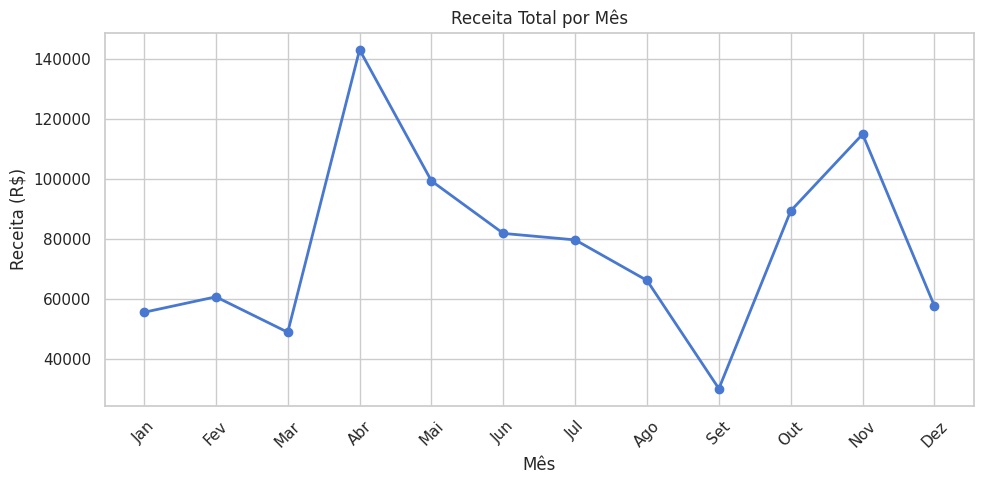

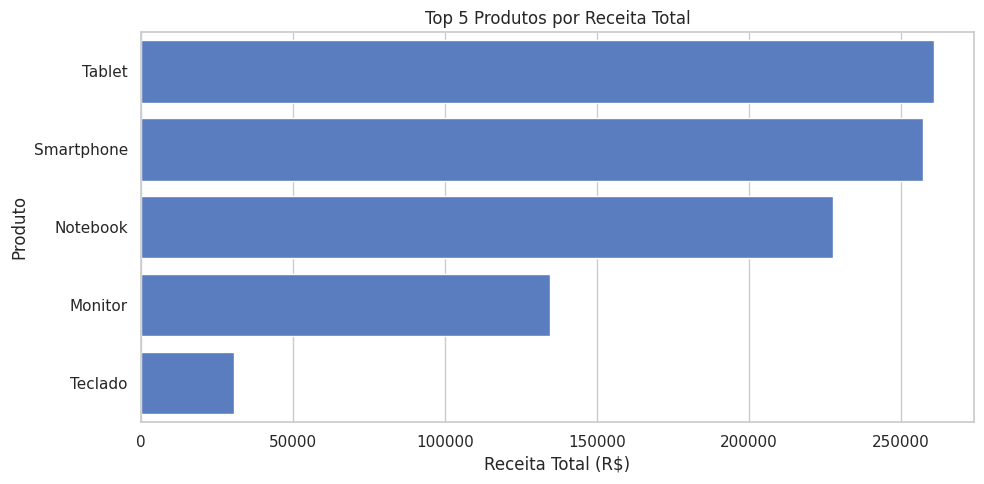

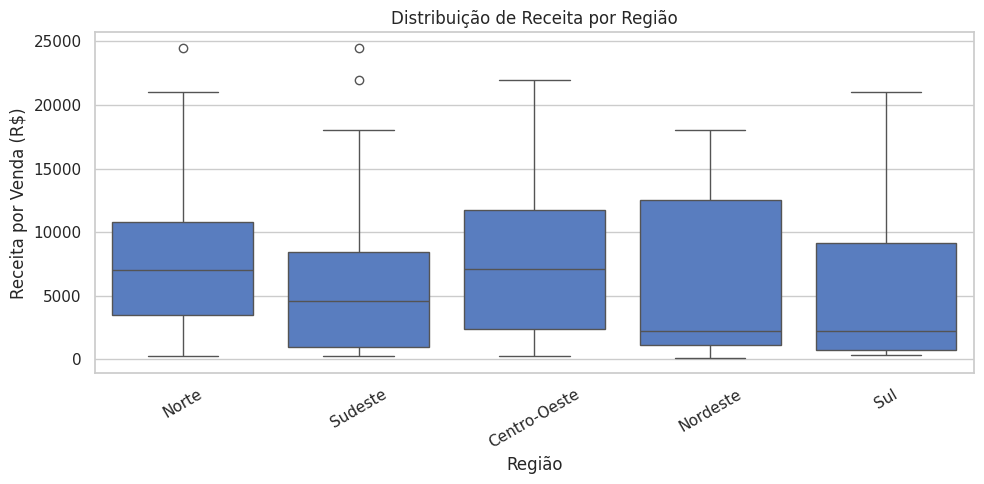


3 gráficos salvos em: outputs/graficos

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

JSON lido de volta para confirmação:
{
  "media": 6928.73,
  "mediana": 5100.0,
  "desvio_padrao": 6449.66,
  "total": 928450.0,
  "p25": 1200.0,
  "p75": 10800.0,
  "acima_da_media": 60.0
}

Dataset final salvo em: data/final/vendas_final.csv

[Sucesso] Pipeline concluído! Todos os passos foram executados e arquivos gerados.


In [ ]:
executar_pipeline_analise()

```markdown
# Tutorial Detalhado: Orquestração do Pipeline de Análise Preditiva

Este tutorial irá guiá-lo(a) através de cada etapa do pipeline de análise de dados, explicando o propósito de cada requisito funcional (RF), como o código o implementa e o que você pode esperar de saída no seu notebook Colab. Para seguir, basta ter o notebook com as funções e a função `executar_pipeline_analise()` definida, e executar essa função.

## Visão Geral do Pipeline (`executar_pipeline_analise()`)

A função `executar_pipeline_analise()` atua como a orquestradora central do projeto. Ela garante que todas as etapas, desde a geração do dataset até a exportação final, sejam executadas na ordem correta. Ao executar esta função, você verá uma série de mensagens e saídas que detalham o progresso de cada RF.

**Onde executar:** Basta executar a célula que contém a chamada para `executar_pipeline_analise()`.

**Saída Esperada Inicial:**
```
[Pipeline] Iniciando processamento dos dados...
```

Esta mensagem indica que o pipeline foi iniciado e as pastas de output (`data/raw`, `data/processed`, `data/final`, `outputs`, `outputs/graficos`) estão sendo criadas.

---

## RF01 – Criar o Dataset de Vendas

**Propósito:** Gerar um conjunto de dados sintéticos de vendas, incluindo valores intencionalmente 'sujos' (nulos, strings com espaços, datas inválidas, outliers), para simular um cenário real e testar as capacidades de limpeza e tratamento do pipeline.

**Implementação (`gerar_dataset_vendas()`):**
- Define uma `seed` para garantir a reprodutibilidade dos dados gerados (os dados serão sempre os mesmos a cada execução).
- Cria listas de produtos, preços, categorias e regiões.
- Gera `n_registros` (padrão: 150) de vendas com dados como ID do cliente, produto, quantidade, preço unitário e data.
- **Introduz propositalmente erros**: valores `None` para quantidade e preço, espaços extras em nomes de produtos e datas no formato "DATA INVALIDA".
- O DataFrame gerado (`df_bruto`) é salvo no caminho `data/raw/vendas.csv`.

**Saída Esperada:**
```
Dataset bruto gerado com 150 registros e salvo em data/raw/vendas.csv.
```

---

## RF02 – Inspecionar e Descrever os Dados

**Propósito:** Realizar uma primeira análise exploratória para entender a estrutura, tipos de dados, presença de valores nulos e estatísticas básicas do dataset bruto. Isso ajuda a identificar os problemas que precisam ser resolvidos.

**Implementação (`inspecionar_dados()`):**
- Recebe um DataFrame (`df_bruto`).
- Imprime o `shape` (número de linhas e colunas) do DataFrame.
- Lista as `colunas` existentes.
- Mostra os `dtypes` (tipos de dados) de cada coluna, o que é crucial para identificar colunas que precisam de conversão (ex: data como `object`, quantidade como `float`).
- Exibe a contagem de `valores nulos por coluna`, destacando onde estão os dados faltantes.
- Apresenta as `primeiras 5 linhas` (`.head()`) do DataFrame para uma visualização rápida dos dados.
- Mostra `estatísticas descritivas` (`.describe()`) para colunas numéricas (média, desvio padrão, mínimo, máximo, quartis) e também para colunas categóricas (contagem, único, top, frequência) se `include='all'` for usado.

**Saída Esperada:**
```
=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
(Tabela com as primeiras 5 linhas do df_bruto, incluindo dados sujos)

Estatísticas descritivas:
(Tabela com as estatísticas descritivas do df_bruto)
```

**Observações:** Note que `data_venda` é `object` (string) e `quantidade`/`preco_unitario` são `float64` devido aos `None` e ainda têm nulos.

---

## RF03 – Limpar e Tratar os Dados

**Propósito:** Corrigir os problemas identificados na inspeção inicial, garantindo que o dataset esteja pronto para análises e cálculos. Isso inclui normalizar strings, tratar datas inválidas e remover/preencher valores nulos.

**Implementação (`limpar_dados()`):**
- O pipeline chama `limpar_dados(df_bruto)`. Esta função realiza as seguintes sub-etapas:
    1.  **Normalização de Strings (`limpar_strings_regex`):** Utiliza expressões regulares para remover espaços extras no início/fim e colapsar múltiplos espaços internos em colunas de texto (ex: `"  Notebook  "` vira `"Notebook"`).
    2.  **Conversão de Datas:** Converte a coluna `data_venda` para o tipo datetime. Datas que não puderem ser convertidas (ex: `"DATA INVALIDA"`) são transformadas em `NaT` (Not a Time) usando `errors="coerce"`.
    3.  **Remoção de Datas Inválidas:** As linhas com `NaT` na coluna `data_venda` são removidas.
    4.  **Remoção de Nulos Críticos:** Linhas que ainda possuem valores nulos nas colunas `quantidade` ou `preco_unitario` são removidas, pois são essenciais para os cálculos de receita.
    5.  **Garantia de Tipos Numéricos:** As colunas `quantidade` e `preco_unitario` são convertidas para `int` e `float`, respectivamente, garantindo os tipos corretos para cálculos.
- Retorna o DataFrame limpo (`df_v1`) e um dicionário `relatorio_limpeza` detalhando as operações.
- O DataFrame limpo (`df_v1`) é salvo em `data/processed/v1_com_outliers/vendas_v1.csv`.

**Saída Esperada:**
```
=== RELATORIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 6
  registros_iniciais: 150
  registros_finais: 140
  registros_removidos_total: 10

v1 salva em data/processed/v1_com_outliers/vendas_v1.csv
```

**Observações:** O relatório mostra claramente quantos registros foram removidos em cada etapa da limpeza, e o total de linhas do dataset. O `df_v1` agora contém dados limpos, mas ainda pode ter outliers.

---

## RF04 – Detectar e Tratar Outliers

**Propósito:** Identificar e remover (ou ajustar) valores extremos que podem distorcer a análise estatística. O pipeline utiliza o método do Intervalo Interquartil (IQR) para essa tarefa.

**Implementação (`tratar_outliers()`):**
- Antes de chamar `tratar_outliers`, uma coluna temporária `receita_total` é calculada em `df_v1_tmp` para permitir a detecção de outliers nessa métrica.
- O pipeline chama `tratar_outliers(df_v1_tmp, colunas=["quantidade", "receita_total"], metodo='remover')`.
- Para cada coluna especificada (`quantidade` e `receita_total`):
    - Calcula o primeiro quartil (Q1) e o terceiro quartil (Q3).
    - Calcula o IQR (`Q3 - Q1`).
    - Define os limites inferior e superior para outliers (`Q1 - 1.5 * IQR` e `Q3 + 1.5 * IQR`).
    - Conta e imprime quantos outliers foram detectados fora desses limites.
    - **`metodo='remover'`:** As linhas que contêm outliers nessas colunas são completamente removidas do DataFrame. Isso significa que alguns registros serão perdidos, mas os dados restantes serão mais consistentes.
- A coluna temporária `receita_total` é removida.
- O DataFrame resultante (`df_v2`), agora sem outliers, é salvo em `data/processed/v2_outliers_tratado/vendas_v2.csv`.

**Saída Esperada:**
```
=== DETECÇÃO E TRATAMENTO DE OUTLIERS ===
  quantidade: 0 outliers detectados (lim_inf=-4.50, lim_sup=15.50)
  receita_total: 6 outliers detectados (lim_inf=-14006.25, lim_sup=26643.75)

v1 = 140 linhas (com outliers)
v2 = 134 linhas (outliers removidos)
Diferença = 6 linhas removidas
v2 salva em data/processed/v2_outliers_tratado/vendas_v2.csv
```

**Observações:** A saída mostra quantos outliers foram encontrados e os limites utilizados. É crucial notar a diferença no número de linhas entre `df_v1` e `df_v2`, indicando as linhas removidas.

---

## RF05 – Criar Colunas Derivadas com Transformações

**Propósito:** Enriquecer o dataset com novas informações que não estavam presentes nos dados brutos, mas que são cruciais para análises mais aprofundadas, como receita total por venda, componentes de data e categorização de valor de vendas.

**Implementação (`criar_colunas_derivadas()`):**
- O pipeline chama `criar_colunas_derivadas(df_v2)`. Esta função cria as seguintes colunas no `df_final`:
    - **`receita_total`**: Calculada como `quantidade * preco_unitario` para cada venda. Esta é uma métrica fundamental.
    - **`mes`**: Extrai o mês da `data_venda` (formato numérico, 1-12).
    - **`trimestre`**: Extrai o trimestre da `data_venda` (ex: "Q1", "Q2").
    - **`ano`**: Extrai o ano da `data_venda`.
    - **`faixa_receita_item`**: Categoriza cada venda (`receita_total`) em `"Baixo Valor"`, `"Médio Valor"`, ou `"Alto Valor"` usando `np.select` para uma classificação eficiente baseada em limites de receita.
- O resultado é armazenado em `df_final`, que será a base para todas as análises subsequentes.

**Saída Esperada:**
```
=== COLUNAS DERIVADAS CRIADAS ===
(Tabela mostrando as primeiras linhas do df_final com as novas colunas 'data_venda', 'receita_total', 'mes', 'trimestre', 'faixa_receita_item')
```

**Observações:** Você verá um `display(df.head())` focado nas novas colunas e em `data_venda`, confirmando que foram criadas corretamente.

---

## RF06 – Calcular Métricas Agregadas (Groupby)

**Propósito:** Gerar resumos e estatísticas agregadas do dataset, permitindo entender padrões e tendências de vendas em diferentes granularidades (por mês, produto, categoria, região).

**Implementação (`calcular_metricas()`):**
- O pipeline chama `calcular_metricas(df_final)`. Esta função utiliza `groupby()` e `agg()` do Pandas para calcular:
    - **`metricas["por_mes"]`**: Receita total, quantidade total e número de vendas (`n_vendas`) agregadas por `mes`.
    - **`metricas["top_produtos"]`**: Os 5 produtos com a maior `receita_total`.
    - **`metricas["por_categoria"]`**: A `receita_total` para cada `categoria` de produto.
    - **`metricas["por_regiao"]`**: `receita_total` e `media_ticket` (receita média por transação) para cada `regiao`.
- Todas essas métricas são armazenadas em um dicionário `metricas`.

**Saída Esperada:**
```
=== MÉTRICAS AGREGADAS ===

=== POR MES ===
(Tabela com receita_total, quantidade, n_vendas por mês)

=== TOP PRODUTOS ===
(Tabela com os 5 produtos de maior receita total)

=== POR CATEGORIA ===
(Tabela com receita_total por categoria)

=== POR REGIAO ===
(Tabela com receita_total e media_ticket por região)
```

**Observações:** Cada tabela agregada é exibida no notebook, fornecendo um resumo imediato das principais métricas do negócio.

---

## RF07 – Segmentar Clientes por Nível de Gasto

**Propósito:** Classificar os clientes em diferentes segmentos (Bronze, Prata, Ouro) com base no seu gasto total. Isso é útil para estratégias de marketing e fidelização.

**Implementação (`segmentar_clientes()`):**
- O pipeline chama `segmentar_clientes(df_final)`.
- Primeiro, agrupa o `df_final` por `cliente` e calcula o `total_gasto` de cada um.
- Em seguida, aplica uma função lambda para categorizar cada cliente:
    - **"Ouro"**: `total_gasto` > R$ 15.000
    - **"Prata"**: R$ 5.000 <= `total_gasto` <= R$ 15.000
    - **"Bronze"**: `total_gasto` < R$ 5.000
- O DataFrame `clientes_segmentados` (com `cliente`, `total_gasto`, `segmento`) é retornado.

**Saída Esperada:**
```
=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
(Tabela com os 10 clientes de maior gasto e seus segmentos)

Distribuição de segmentos:
(Contagem de clientes por segmento: Bronze, Prata, Ouro)
```

**Observações:** Você verá uma tabela com os principais clientes e sua classificação, seguida de um resumo da distribuição de clientes por segmento.

---

## RF08 – Calcular Estatísticas com NumPy

**Propósito:** Demonstrar o uso de NumPy para cálculos estatísticos eficientes, explorando conceitos como operações vetorizadas, broadcasting e indexação booleana.

**Implementação (`calcular_estatisticas_numpy()`):**
- O pipeline chama `calcular_estatisticas_numpy(df_final)`.
- Converte a coluna `receita_total` do DataFrame para um array NumPy puro (`receitas`).
- Calcula diversas estatísticas usando funções NumPy:
    - `np.mean()`: Média da receita.
    - `np.median()`: Mediana da receita.
    - `np.std()`: Desvio padrão da receita.
    - `np.sum()`: Total de todas as receitas.
    - `np.percentile()`: Percentis 25 e 75 da receita.
- Demonstra **Broadcasting**: Calcula a participação percentual de cada venda no total (`receitas / receitas.sum() * 100`).
- Demonstra **Boolean Indexing**: Conta quantas vendas estão `acima_da_media` usando um filtro booleano no array.
- As estatísticas são armazenadas em um dicionário `estatisticas`.

**Saída Esperada:**
```
  Participação das 5 maiores vendas no total: [XX.XX YY.YY ...]%

=== ESTATÍSTICAS COM NUMPY ===
  media: R$ X.XX
  mediana: R$ X.XX
  desvio_padrao: R$ X.XX
  total: R$ X.XX
  p25: R$ X.XX
  p75: R$ X.XX
  acima_da_media: N vendas
```

**Observações:** A saída mostra as estatísticas formatadas, a participação das maiores vendas e o número de vendas acima da média, ilustrando o poder do NumPy.

---

## RF09 – Criar Visualizações (Matplotlib e Seaborn)

**Propósito:** Gerar representações gráficas dos dados para facilitar a compreensão de tendências, distribuições e comparações, tornando a análise mais intuitiva.

**Implementação (`gerar_visualizacoes()`):**
- O pipeline chama `gerar_visualizacoes(df_final, metricas)`.
- Cria o diretório `outputs/graficos` para salvar as imagens.
- Define um estilo global (`sns.set_theme()`) para os gráficos.
- Gera e salva três gráficos em formato PNG:
    1.  **Gráfico de Linha (Receita Total por Mês)**: Usa `matplotlib.pyplot.plot` para mostrar a evolução da receita ao longo do tempo. Salvo como `outputs/graficos/receita_por_mes.png`.
    2.  **Gráfico de Barras Horizontais (Top 5 Produtos por Receita Total)**: Usa `seaborn.barplot` para exibir um ranking claro dos produtos mais lucrativos. Salvo como `outputs/graficos/top_produtos.png`.
    3.  **Boxplot (Distribuição de Receita por Região)**: Usa `seaborn.boxplot` para visualizar a distribuição (mediana, quartis, outliers) da receita por venda em cada região, permitindo comparar a dispersão dos dados. Salvo como `outputs/graficos/dist_regiao.png`.
- Cada gráfico é exibido no notebook e, em seguida, `plt.close()` é usado para liberar a memória.

**Saída Esperada:**
```
(Exibição do Gráfico de Linha: Receita Total por Mês)
(Exibição do Gráfico de Barras: Top 5 Produtos por Receita Total)
(Exibição do Boxplot: Distribuição de Receita por Região)

3 gráficos salvos em: outputs/graficos
```

**Observações:** Você verá os três gráficos plotados diretamente no output do notebook, seguidos da confirmação de que foram salvos no diretório `outputs/graficos`.

---

## RF11 – Ler e Escrever Arquivos (CSV e JSON)

**Propósito:** Persistir os resultados da análise em formatos padronizados (CSV e JSON), tornando-os acessíveis para outras ferramentas, sistemas ou equipes.

**Implementação (`exportar_resultados()`):**
- O pipeline chama `exportar_resultados(metricas, clientes_segmentados, estatisticas)`.
- Cria o diretório `outputs` se ainda não existir.
- **Exporta para CSV**: Salva as tabelas de métricas mensais (`metricas["por_mes"]`) e a segmentação de clientes (`clientes_segmentados`) em arquivos CSV (`outputs/metricas_por_mes.csv` e `outputs/segmentacao_clientes.csv`). `encoding="utf-8-sig"` é usado para garantir a compatibilidade com o Microsoft Excel.
- **Exporta para JSON**: Salva o dicionário `estatisticas` (do RF08) em formato JSON (`outputs/estatisticas_gerais.json`). `indent=2` é usado para formatar o JSON de forma legível.
- **Confirmação de Leitura JSON**: Após salvar, o arquivo JSON é lido de volta para confirmar que foi gravado corretamente, e seu conteúdo é impresso.

**Saída Esperada:**
```
CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

JSON lido de volta para confirmação:
{
  "media": X.XX,
  "mediana": X.XX,
  ...
}
```

**Observações:** Você receberá mensagens confirmando a exportação de cada arquivo e verá o conteúdo do JSON lido de volta, garantindo a integridade dos dados salvos.

---

## RF12 – Consolidar a Análise e Salvar o Dataset Final

**Propósito:** Salvar a versão final e completamente processada do dataset de vendas. Este é o dataset `df_final` que contém todas as limpezas, tratamento de outliers e colunas derivadas.

**Implementação (`consolidar_e_salvar_final()`):**
- O pipeline chama `consolidar_e_salvar_final(df_final)`.
- Cria o diretório `data/final` se ainda não existir.
- Salva o DataFrame `df_final` no caminho `data/final/vendas_final.csv` sem o índice do Pandas.

**Saída Esperada:**
```
Dataset final salvo em: data/final/vendas_final.csv
```

**Observações:** Esta etapa finaliza a fase de processamento, tornando o dataset final facilmente acessível para futuras análises ou para alimentar modelos preditivos.

---

## Conclusão do Pipeline

Após todas as etapas serem executadas, uma mensagem final indicará a conclusão bem-sucedida do pipeline.

**Saída Esperada:**
```
[Sucesso] Pipeline concluído! Todos os passos foram executados e arquivos gerados.
```

**Onde encontrar os resultados:**
- **Dados Processados:** `data/raw/`, `data/processed/v1_com_outliers/`, `data/processed/v2_outliers_tratado/`, `data/final/`
- **Relatórios e Gráficos:** `outputs/` e `outputs/graficos/`

Este tutorial deve fornecer uma compreensão clara de cada componente do projeto e como eles se integram para formar um pipeline de análise de dados robusto.
```

In [ ]:
import os

print("Arquivos na raiz do diretório:")
for item in os.listdir('.'):
    print(item)

Arquivos na raiz do diretório:
.config
metricas_por_mes.csv
drive
dataset_final.csv
estatisticas_gerais.json
README.md
Tutorial_Video_Projeto.txt
Desenvolvedor(a) em IA para Análise Preditiva [T2].pdf
segmentacao_clientes.csv
data
outputs
sample_data


In [ ]:
import os

def list_files_in_dir(startpath):
    print(f"\nConteúdo do diretório: {startpath}")
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

print("=== Listando arquivos gerados no projeto ===")
list_files_in_dir('data')
list_files_in_dir('outputs')

=== Listando arquivos gerados no projeto ===

Conteúdo do diretório: data
data/
    final/
        vendas_final.csv
    processed/
        v2_outliers_tratado/
            vendas_v2.csv
        v1_com_outliers/
            vendas_v1.csv
    raw/
        vendas.csv

Conteúdo do diretório: outputs
outputs/
    metricas_por_mes.csv
    estatisticas_gerais.json
    segmentacao_clientes.csv
    graficos/
        dist_regiao.png
        top_produtos.png
        receita_por_mes.png


In [ ]:
readme_content = """# Projeto de Análise Preditiva e Tratamento de Dados\n\nEste projeto demonstra um pipeline completo de análise de dados, desde a geração de um dataset sintético até a exportação de resultados e visualizações. Ele foi desenvolvido para atender a uma série de requisitos funcionais (RF01-RF12) focados em limpeza, tratamento, enriquecimento e análise exploratória de dados de vendas.\n\n## Funcionalidades Implementadas\n\n### **RF01 – Criar ou Carregar o Dataset de Vendas**\n- O pipeline inicia com a função `gerar_dataset_vendas()` que cria um dataset sintético de vendas com dados intencionalmente "sujos" (valores nulos, strings com espaços extras, datas inválidas e outliers) para simular um cenário real. O dataset é salvo em `data/raw/vendas.csv`.\n\n### **RF02 – Inspecionar e Descrever os Dados**\n- A função `inspecionar_dados()` é utilizada para realizar uma inspeção inicial do DataFrame bruto, exibindo suas primeiras linhas, shape, tipos de dados, contagem de valores nulos e estatísticas descritivas básicas.\n\n### **RF03 – Limpar e Tratar os Dados**\n- A função `limpar_dados()` realiza a limpeza do dataset em etapas:\n    - Normalização de strings (`limpar_strings_regex`) em colunas de texto (removendo espaços extras).\n    - Conversão da coluna `data_venda` para o tipo datetime, tratando datas inválidas.\n    - Remoção de linhas com valores nulos nas colunas `quantidade` e `preco_unitario`.\n    - Garantia dos tipos numéricos corretos para `quantidade` (int) e `preco_unitario` (float).\n- Um relatório detalhado do processo de limpeza é gerado, informando o número de registros removidos. O dataset limpo é salvo como `data/processed/v1_com_outliers/vendas_v1.csv`.\n\n### **RF04 – Detectar e Tratar Outliers**\n- A função `tratar_outliers()` utiliza o método IQR (Intervalo Interquartil) para identificar e remover outliers nas colunas `quantidade` e `receita_total`.\n- O relatório de execução detalha os limites inferior e superior do IQR e quantos outliers foram detectados e removidos. O dataset com outliers tratados é salvo como `data/processed/v2_outliers_tratado/vendas_v2.csv`.\n\n### **RF05 – Criar Colunas Derivadas com Transformações**\n- A função `criar_colunas_derivadas()` enriquece o dataset com novas informações:\n    - `receita_total`: Calculada como `quantidade * preco_unitario`.\n    - `mes`, `trimestre`, `ano`: Extraídos da coluna `data_venda`.\n    - `faixa_receita_item`: Categoriza o `receita_total` de cada item em 'Baixo Valor', 'Médio Valor' ou 'Alto Valor' usando `np.select` para eficiência.\n\n### **RF06 – Calcular Métricas Agregadas (Groupby)**\n- A função `calcular_metricas()` gera um dicionário de métricas agregadas, incluindo:\n    - Receita total, quantidade e número de vendas por mês.\n    - Top 5 produtos por receita total.\n    - Receita total por categoria.\n    - Receita total e ticket médio por região.\n\n### **RF07 – Segmentar Clientes por Nível de Gasto**\n- A função `segmentar_clientes()` agrupa os clientes pelo `total_gasto` e os classifica em segmentos 'Bronze', 'Prata' ou 'Ouro' com base em limites de gasto predefinidos ( < R$5.000, R$5.000-R$15.000, > R$15.000).\n\n### **RF08 – Calcular Estatísticas com NumPy**\n- A função `calcular_estatisticas_numpy()` demonstra o uso direto do NumPy para calcular estatísticas descritivas sobre a `receita_total` (média, mediana, desvio padrão, total, percentis 25 e 75).\n- Também ilustra o conceito de broadcasting para calcular a participação percentual de cada venda e boolean indexing para contar vendas acima da média.\n\n### **RF09 – Criar Visualizações (Matplotlib e Seaborn)**\n- A função `gerar_visualizacoes()` cria e exporta três gráficos informativos em formato PNG para o diretório `outputs/graficos`:\n    - **Gráfico de Linha**: Receita Total por Mês, mostrando tendências.\n    - **Gráfico de Barras Horizontais**: Top 5 Produtos por Receita Total, para ranking.\n    - **Boxplot**: Distribuição de Receita por Região, para analisar dispersão e outliers entre regiões.\n\n### **RF10 – (Não implementado explicitamente como função separada, mas integrado)**\n- Este requisito funcional, geralmente associado à orquestração, é coberto pela função mestra `executar_pipeline_analise()` que garante a execução sequencial e correta de todas as demais RFs.\n\n### **RF11 – Ler e Escrever Arquivos (CSV e JSON)**\n- A função `exportar_resultados()` salva as métricas e a segmentação de clientes em arquivos CSV (`outputs/metricas_por_mes.csv`, `outputs/segmentacao_clientes.csv`) e as estatísticas NumPy em JSON (`outputs/estatisticas_gerais.json`).\n- A exportação CSV usa `encoding="utf-8-sig"` para compatibilidade com Excel. A exportação JSON formata o arquivo para melhor legibilidade (`indent=2`) e inclui a leitura de volta do JSON para confirmação.\n\n### **RF12 – Consolidar a Análise e Salvar o Dataset Final**\n- A função `consolidar_e_salvar_final()` salva o dataset final processado (`df_final`) em `data/final/vendas_final.csv`, consolidando todas as transformações e limpezas.\n\n## Estrutura de Diretórios e Arquivos Gerados\n\n- `data/raw/vendas.csv`: Dataset bruto inicial.\n- `data/processed/v1_com_outliers/vendas_v1.csv`: Dataset após limpeza e tratamento de strings/datas/nulos (com outliers).\n- `data/processed/v2_outliers_tratado/vendas_v2.csv`: Dataset após tratamento de outliers.\n- `data/final/vendas_final.csv`: Dataset final consolidado com todas as colunas derivadas e transformações.\n- `outputs/graficos/`: Contém os gráficos gerados em formato PNG (`receita_por_mes.png`, `top_produtos.png`, `dist_regiao.png`).\n- `outputs/metricas_por_mes.csv`: Métricas de vendas agregadas por mês.\n- `outputs/segmentacao_clientes.csv`: Segmentação de todos os clientes por nível de gasto.\n- `outputs/estatisticas_gerais.json`: Estatísticas descritivas (média, mediana, desvio padrão, etc.) calculadas com NumPy.\n\n## Tecnologias Utilizadas\n\n- **Python**: Linguagem de programação principal.\n- **Pandas**: Para manipulação e análise de dados (DataFrames).\n- **NumPy**: Para operações numéricas e estatísticas de alta performance.\n- **Matplotlib**: Para criação de gráficos base.\n- **Seaborn**: Para visualizações de dados estatísticos mais atraentes.\n- **json**: Para leitura e escrita de arquivos JSON.\n- **datetime**: Para manipulação de datas e horas.\n- **random**: Para geração de dados sintéticos.\n- **os**: Para manipulação de diretórios e arquivos.\n- **re**: Para operações com expressões regulares (limpeza de strings).\n\n## Como Executar o Projeto\n\n1.  **Ambiente**: Certifique-se de ter Python e as bibliotecas listadas (`pandas`, `numpy`, `matplotlib`, `seaborn`, etc.) instaladas. Se estiver usando Google Colab, a maioria delas já estará disponível.\n2.  **Célula Mestra**: Execute a célula que contém a função `executar_pipeline_analise()` (ou o notebook inteiro).\n3.  **Verificação**: Após a execução, os arquivos CSV, JSON e os gráficos PNG estarão disponíveis nos diretórios `data/` e `outputs/` criados na raiz do projeto.\n"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Arquivo 'README.md' criado com sucesso!")

Arquivo 'README.md' criado com sucesso!


In [ ]:
import os

if os.path.exists('README.md'):
    print("O arquivo 'README.md' foi encontrado com sucesso na raiz do projeto.")
else:
    print("Erro: O arquivo 'README.md' NÃO foi encontrado.")

O arquivo 'README.md' foi encontrado com sucesso na raiz do projeto.


In [ ]:
tutorial_content = """# Tutorial Detalhado: Orquestração do Pipeline de Análise Preditiva

Este tutorial irá guiá-lo(a) através de cada etapa do pipeline de análise de dados, explicando o propósito de cada requisito funcional (RF), como o código o implementa e o que você pode esperar de saída no seu notebook Colab. Para seguir, basta ter o notebook com as funções e a função `executar_pipeline_analise()` definida, e executar essa função.

## Visão Geral do Pipeline (`executar_pipeline_analise()`)

A função `executar_pipeline_analise()` atua como a orquestradora central do projeto. Ela garante que todas as etapas, desde a geração do dataset até a exportação final, sejam executadas na ordem correta. Ao executar esta função, você verá uma série de mensagens e saídas que detalham o progresso de cada RF.

**Onde executar:** Basta executar a célula que contém a chamada para `executar_pipeline_analise()`.

**Saída Esperada Inicial:**
```
[Pipeline] Iniciando processamento dos dados...
```

Esta mensagem indica que o pipeline foi iniciado e as pastas de output (`data/raw`, `data/processed`, `data/final`, `outputs`, `outputs/graficos`) estão sendo criadas.

---

## RF01 – Criar o Dataset de Vendas

**Propósito:** Gerar um conjunto de dados sintéticos de vendas, incluindo valores intencionalmente 'sujos' (nulos, strings com espaços, datas inválidas, outliers), para simular um cenário real e testar as capacidades de limpeza e tratamento do pipeline.

**Implementação (`gerar_dataset_vendas()`):**
- Define uma `seed` para garantir a reprodutibilidade dos dados gerados (os dados serão sempre os mesmos a cada execução).
- Cria listas de produtos, preços, categorias e regiões.
- Gera `n_registros` (padrão: 150) de vendas com dados como ID do cliente, produto, quantidade, preço unitário e data.
- **Introduz propositalmente erros**: valores `None` para quantidade e preço, espaços extras em nomes de produtos e datas no formato "DATA INVALIDA".
- O DataFrame gerado (`df_bruto`) é salvo no caminho `data/raw/vendas.csv`.

**Saída Esperada:**
```
Dataset bruto gerado com 150 registros e salvo em data/raw/vendas.csv.
```

---

## RF02 – Inspecionar e Descrever os Dados

**Propósito:** Realizar uma primeira análise exploratória para entender a estrutura, tipos de dados, presença de valores nulos e estatísticas básicas do dataset bruto. Isso ajuda a identificar os problemas que precisam ser resolvidos.

**Implementação (`inspecionar_dados()`):**
- Recebe um DataFrame (`df_bruto`).
- Imprime o `shape` (número de linhas e colunas) do DataFrame.
- Lista as `colunas` existentes.
- Mostra os `dtypes` (tipos de dados) de cada coluna, o que é crucial para identificar colunas que precisam de conversão (ex: data como `object`, quantidade como `float`).
- Exibe a contagem de `valores nulos por coluna`, destacando onde estão os dados faltantes.
- Apresenta as `primeiras 5 linhas` (`.head()`) do DataFrame para uma visualização rápida dos dados.
- Mostra `estatísticas descritivas` (`.describe()`) para colunas numéricas (média, desvio padrão, mínimo, máximo, quartis) e também para colunas categóricas (contagem, único, top, frequência) se `include='all'` for usado.

**Saída Esperada:**
```
=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
(Tabela com as primeiras 5 linhas do df_bruto, incluindo dados sujos)

Estatísticas descritivas:
(Tabela com as estatísticas descritivas do df_bruto)
```

**Observações:** Note que `data_venda` é `object` (string) e `quantidade`/`preco_unitario` são `float64` devido aos `None` e ainda têm nulos.

---

## RF03 – Limpar e Tratar os Dados

**Propósito:** Corrigir os problemas identificados na inspeção inicial, garantindo que o dataset esteja pronto para análises e cálculos. Isso inclui normalizar strings, tratar datas inválidas e remover/preencher valores nulos.

**Implementação (`limpar_dados()`):**
- O pipeline chama `limpar_dados(df_bruto)`. Esta função realiza as seguintes sub-etapas:
    1.  **Normalização de Strings (`limpar_strings_regex`):** Utiliza expressões regulares para remover espaços extras no início/fim e colapsar múltiplos espaços internos em colunas de texto (ex: `"  Notebook  "` vira `"Notebook"`).
    2.  **Conversão de Datas:** Converte a coluna `data_venda` para o tipo datetime. Datas que não puderem ser convertidas (ex: `"DATA INVALIDA"`) são transformadas em `NaT` (Not a Time) usando `errors="coerce"`.
    3.  **Remoção de Datas Inválidas:** As linhas com `NaT` na coluna `data_venda` são removidas.
    4.  **Remoção de Nulos Críticos:** Linhas que ainda possuem valores nulos nas colunas `quantidade` ou `preco_unitario` são removidas, pois são essenciais para os cálculos de receita.
    5.  **Garantia de Tipos Numéricos:** As colunas `quantidade` e `preco_unitario` são convertidas para `int` e `float`, respectivamente, garantindo os tipos corretos para cálculos.
- Retorna o DataFrame limpo (`df_v1`) e um dicionário `relatorio_limpeza` detalhando as operações.
- O DataFrame limpo (`df_v1`) é salvo em `data/processed/v1_com_outliers/vendas_v1.csv`.

**Saída Esperada:**
```
=== RELATORIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 6
  registros_iniciais: 150
  registros_finais: 140
  registros_removidos_total: 10

v1 salva em data/processed/v1_com_outliers/vendas_v1.csv
```

**Observações:** O relatório mostra claramente quantos registros foram removidos em cada etapa da limpeza, e o total de linhas do dataset. O `df_v1` agora contém dados limpos, mas ainda pode ter outliers.

---

## RF04 – Detectar e Tratar Outliers

**Propósito:** Identificar e remover (ou ajustar) valores extremos que podem distorcer a análise estatística. O pipeline utiliza o método do Intervalo Interquartil (IQR) para essa tarefa.

**Implementação (`tratar_outliers()`):**
- Antes de chamar `tratar_outliers`, uma coluna temporária `receita_total` é calculada em `df_v1_tmp` para permitir a detecção de outliers nessa métrica.
- O pipeline chama `tratar_outliers(df_v1_tmp, colunas=["quantidade", "receita_total"], metodo='remover')`.
- Para cada coluna especificada (`quantidade` e `receita_total`):
    - Calcula o primeiro quartil (Q1) e o terceiro quartil (Q3).
    - Calcula o IQR (`Q3 - Q1`).
    - Define os limites inferior e superior para outliers (`Q1 - 1.5 * IQR` e `Q3 + 1.5 * IQR`).
    - Conta e imprime quantos outliers foram detectados fora desses limites.
    - **`metodo='remover'`:** As linhas que contêm outliers nessas colunas são completamente removidas do DataFrame. Isso significa que alguns registros serão perdidos, mas os dados restantes serão mais consistentes.
- A coluna temporária `receita_total` é removida.
- O DataFrame resultante (`df_v2`), agora sem outliers, é salvo em `data/processed/v2_outliers_tratado/vendas_v2.csv`.

**Saída Esperada:**
```
=== DETECÇÃO E TRATAMENTO DE OUTLIERS ===
  quantidade: 0 outliers detectados (lim_inf=-4.50, lim_sup=15.50)
  receita_total: 6 outliers detectados (lim_inf=-14006.25, lim_sup=26643.75)

v1 = 140 linhas (com outliers)
v2 = 134 linhas (outliers removidos)
Diferença = 6 linhas removidas
v2 salva em data/processed/v2_outliers_tratado/vendas_v2.csv
```

**Observações:** A saída mostra quantos outliers foram encontrados e os limites utilizados. É crucial notar a diferença no número de linhas entre `df_v1` e `df_v2`, indicando as linhas removidas.

---

## RF05 – Criar Colunas Derivadas com Transformações

**Propósito:** Enriquecer o dataset com novas informações que não estavam presentes nos dados brutos, mas que são cruciais para análises mais aprofundadas, como receita total por venda, componentes de data e categorização de valor de vendas.

**Implementação (`criar_colunas_derivadas()`):**
- O pipeline chama `criar_colunas_derivadas(df_v2)`. Esta função cria as seguintes colunas no `df_final`:
    - **`receita_total`**: Calculada como `quantidade * preco_unitario` para cada venda. Esta é uma métrica fundamental.
    - **`mes`**: Extrai o mês da `data_venda` (formato numérico, 1-12).
    - **`trimestre`**: Extrai o trimestre da `data_venda` (ex: "Q1", "Q2").
    - **`ano`**: Extrai o ano da `data_venda`.
    - **`faixa_receita_item`**: Categoriza cada venda (`receita_total`) em `"Baixo Valor"`, `"Médio Valor"`, ou `"Alto Valor"` usando `np.select` para uma classificação eficiente baseada em limites de receita.
- O resultado é armazenado em `df_final`, que será a base para todas as análises subsequentes.

**Saída Esperada:**
```
=== COLUNAS DERIVADAS CRIADAS ===
(Tabela mostrando as primeiras linhas do df_final com as novas colunas 'data_venda', 'receita_total', 'mes', 'trimestre', 'faixa_receita_item')
```

**Observações:** Você verá um `display(df.head())` focado nas novas colunas e em `data_venda`, confirmando que foram criadas corretamente.

---

## RF06 – Calcular Métricas Agregadas (Groupby)

**Propósito:** Gerar resumos e estatísticas agregadas do dataset, permitindo entender padrões e tendências de vendas em diferentes granularidades (por mês, produto, categoria, região).

**Implementação (`calcular_metricas()`):**
- O pipeline chama `calcular_metricas(df_final)`. Esta função utiliza `groupby()` e `agg()` do Pandas para calcular:
    - **`metricas["por_mes"]`**: Receita total, quantidade total e número de vendas (`n_vendas`) agregadas por `mes`.
    - **`metricas["top_produtos"]`**: Os 5 produtos com a maior `receita_total`.
    - **`metricas["por_categoria"]`**: A `receita_total` para cada `categoria` de produto.
    - **`metricas["por_regiao"]`**: `receita_total` e `media_ticket` (receita média por transação) para cada `regiao`.
- Todas essas métricas são armazenadas em um dicionário `metricas`.

**Saída Esperada:**
```
=== MÉTRICAS AGREGADAS ===

=== POR MES ===
(Tabela com receita_total, quantidade, n_vendas por mês)

=== TOP PRODUTOS ===
(Tabela com os 5 produtos de maior receita total)

=== POR CATEGORIA ===
(Tabela com receita_total por categoria)

=== POR REGIAO ===
(Tabela com receita_total e media_ticket por região)
```

**Observações:** Cada tabela agregada é exibida no notebook, fornecendo um resumo imediato das principais métricas do negócio.

---

## RF07 – Segmentar Clientes por Nível de Gasto

**Propósito:** Classificar os clientes em diferentes segmentos (Bronze, Prata, Ouro) com base no seu gasto total. Isso é útil para estratégias de marketing e fidelização.

**Implementação (`segmentar_clientes()`):**
- O pipeline chama `segmentar_clientes(df_final)`.
- Primeiro, agrupa o `df_final` por `cliente` e calcula o `total_gasto` de cada um.
- Em seguida, aplica uma função lambda para categorizar cada cliente:
    - **"Ouro"**: `total_gasto` > R$ 15.000
    - **"Prata"**: R$ 5.000 <= `total_gasto` <= R$ 15.000
    - **"Bronze"**: `total_gasto` < R$ 5.000
- O DataFrame `clientes_segmentados` (com `cliente`, `total_gasto`, `segmento`) é retornado.

**Saída Esperada:**
```
=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
(Tabela com os 10 clientes de maior gasto e seus segmentos)

Distribuição de segmentos:
(Contagem de clientes por segmento: Bronze, Prata, Ouro)
```

**Observações:** Você verá uma tabela com os principais clientes e sua classificação, seguida de um resumo da distribuição de clientes por segmento.

---

## RF08 – Calcular Estatísticas com NumPy

**Propósito:** Demonstrar o uso de NumPy para cálculos estatísticos eficientes, explorando conceitos como operações vetorizadas, broadcasting e indexação booleana.

**Implementação (`calcular_estatisticas_numpy()`):**
- O pipeline chama `calcular_estatisticas_numpy(df_final)`.
- Converte a coluna `receita_total` do DataFrame para um array NumPy puro (`receitas`).
- Calcula diversas estatísticas usando funções NumPy:
    - `np.mean()`: Média da receita.
    - `np.median()`: Mediana da receita.
    - `np.std()`: Desvio padrão da receita.
    - `np.sum()`: Total de todas as receitas.
    - `np.percentile()`: Percentis 25 e 75 da receita.
- Demonstra **Broadcasting**: Calcula a participação percentual de cada venda no total (`receitas / receitas.sum() * 100`).
- Demonstra **Boolean Indexing**: Conta quantas vendas estão `acima_da_media` usando um filtro booleano no array.
- As estatísticas são armazenadas em um dicionário `estatisticas`.

**Saída Esperada:**
```
  Participação das 5 maiores vendas no total: [XX.XX YY.YY ... ]%

=== ESTATÍSTICAS COM NUMPY ===
  media: R$ X.XX
  mediana: R$ X.XX
  desvio_padrao: R$ X.XX
  total: R$ X.XX
  p25: R$ X.XX
  p75: R$ X.XX
  acima_da_media: N vendas
```

**Observações:** A saída mostra as estatísticas formatadas, a participação das maiores vendas e o número de vendas acima da média, ilustrando o poder do NumPy.

---

## RF09 – Criar Visualizações (Matplotlib e Seaborn)

**Propósito:** Gerar representações gráficas dos dados para facilitar a compreensão de tendências, distribuições e comparações, tornando a análise mais intuitiva.

**Implementação (`gerar_visualizacoes()`):**
- O pipeline chama `gerar_visualizacoes(df_final, metricas)`.
- Cria o diretório `outputs/graficos` para salvar as imagens.
- Define um estilo global (`sns.set_theme()`) para os gráficos.
- Gera e salva três gráficos em formato PNG:
    1.  **Gráfico de Linha (Receita Total por Mês)**: Usa `matplotlib.pyplot.plot` para mostrar a evolução da receita ao longo do tempo. Salvo como `outputs/graficos/receita_por_mes.png`.
    2.  **Gráfico de Barras Horizontais (Top 5 Produtos por Receita Total)**: Usa `seaborn.barplot` para exibir um ranking claro dos produtos mais lucrativos. Salvo como `outputs/graficos/top_produtos.png`.
    3.  **Boxplot (Distribuição de Receita por Região)**: Usa `seaborn.boxplot` para visualizar a distribuição (mediana, quartis, outliers) da receita por venda em cada região, permitindo comparar a dispersão dos dados. Salvo como `outputs/graficos/dist_regiao.png`.
- Cada gráfico é exibido no notebook e, em seguida, `plt.close()` é usado para liberar a memória.

**Saída Esperada:**
```
(Exibição do Gráfico de Linha: Receita Total por Mês)
(Exibição do Gráfico de Barras: Top 5 Produtos por Receita Total)
(Exibição do Boxplot: Distribuição de Receita por Região)

3 gráficos salvos em: outputs/graficos
```

**Observações:** Você verá os três gráficos plotados diretamente no output do notebook, seguidos da confirmação de que foram salvos no diretório `outputs/graficos`.

---

## RF11 – Ler e Escrever Arquivos (CSV e JSON)

**Propósito:** Persistir os resultados da análise em formatos padronizados (CSV e JSON), tornando-os acessíveis para outras ferramentas, sistemas ou equipes.

**Implementação (`exportar_resultados()`):**
- O pipeline chama `exportar_resultados(metricas, clientes_segmentados, estatisticas)`.
- Cria o diretório `outputs` se ainda não existir.
- **Exporta para CSV**: Salva as tabelas de métricas mensais (`metricas["por_mes"]`) e a segmentação de clientes (`clientes_segmentados`) em arquivos CSV (`outputs/metricas_por_mes.csv` e `outputs/segmentacao_clientes.csv`). `encoding="utf-8-sig"` é usado para garantir a compatibilidade com o Microsoft Excel.
- **Exporta para JSON**: Salva o dicionário `estatisticas` (do RF08) em formato JSON (`outputs/estatisticas_gerais.json`). `indent=2` é usado para formatar o JSON de forma legível.
- **Confirmação de Leitura JSON**: Após salvar, o arquivo JSON é lido de volta para confirmar que foi gravado corretamente, e seu conteúdo é impresso.

**Saída Esperada:**
```
CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

JSON lido de volta para confirmação:
{
  "media": X.XX,
  "mediana": X.XX,
  ...
}
```

**Observações:** Você receberá mensagens confirmando a exportação de cada arquivo e verá o conteúdo do JSON lido de volta, garantindo a integridade dos dados salvos.

---

## RF12 – Consolidar a Análise e Salvar o Dataset Final

**Propósito:** Salvar a versão final e completamente processada do dataset de vendas. Este é o dataset `df_final` que contém todas as limpezas, tratamento de outliers e colunas derivadas.

**Implementação (`consolidar_e_salvar_final()`):**
- O pipeline chama `consolidar_e_salvar_final(df_final)`.
- Cria o diretório `data/final` se ainda não existir.
- Salva o DataFrame `df_final` no caminho `data/final/vendas_final.csv` sem o índice do Pandas.

**Saída Esperada:**
```
Dataset final salvo em: data/final/vendas_final.csv
```

**Observações:** Esta etapa finaliza a fase de processamento, tornando o dataset final facilmente acessível para futuras análises ou para alimentar modelos preditivos.

---

## Conclusão do Pipeline

Após todas as etapas serem executadas, uma mensagem final indicará a conclusão bem-sucedida do pipeline.

**Saída Esperada:**
```
[Sucesso] Pipeline concluído! Todos os passos foram executados e arquivos gerados.
```

**Onde encontrar os resultados:**
- **Dados Processados:** `data/raw/`, `data/processed/v1_com_outliers/`, `data/processed/v2_outliers_tratado/`, `data/final/`
- **Relatórios e Gráficos:** `outputs/` e `outputs/graficos/`

Este tutorial deve fornecer uma compreensão clara de cada componente do projeto e como eles se integram para formar um pipeline de análise de dados robusto.
"""

with open("Tutorial_Video_Projeto.txt", "w", encoding="utf-8") as f:
    f.write(tutorial_content)

print("Arquivo 'Tutorial_Video_Projeto.txt' criado com sucesso!")

Arquivo 'Tutorial_Video_Projeto.txt' criado com sucesso!
